In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.table import Table
from itertools import cycle
# import hdbscan
import glob

import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rc
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as colors

matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
# plt.style.use('dark_background')

In [2]:
path = '/pscratch/sd/v/vtorresg/umap_analysis/data/loa/data/processed/umap/umap_20230227_8643.npz'

In [3]:
file = np.load(path, allow_pickle=True)
file.files

['embedding', 'labels', 'outlier_mask', 'categories', 'ids', 'petals']

In [ ]:
def decode_categories(categories):
    if categories.dtype.kind in {'S'}:
        return np.char.decode(categories, 'utf-8', errors='ignore')
    if categories.dtype == object and len(categories) > 0 and isinstance(categories[0], (bytes, bytearray)):
        return np.array([x.decode('utf-8', 'ignore') for x in categories], dtype=str)
    return categories.astype(str)

In [ ]:
embedding = file['embedding']
outlier_mask = file['outlier_mask']
# categories = decode_categories(file['categories'])

In [6]:
embedding.shape

(4105, 2)

In [8]:
# uniq_cats, inv = np.unique(categories, return_inverse=True)

In [ ]:
base_colors = ['orange', 'royalblue', 'navy']
color_cycle = cycle(base_colors)

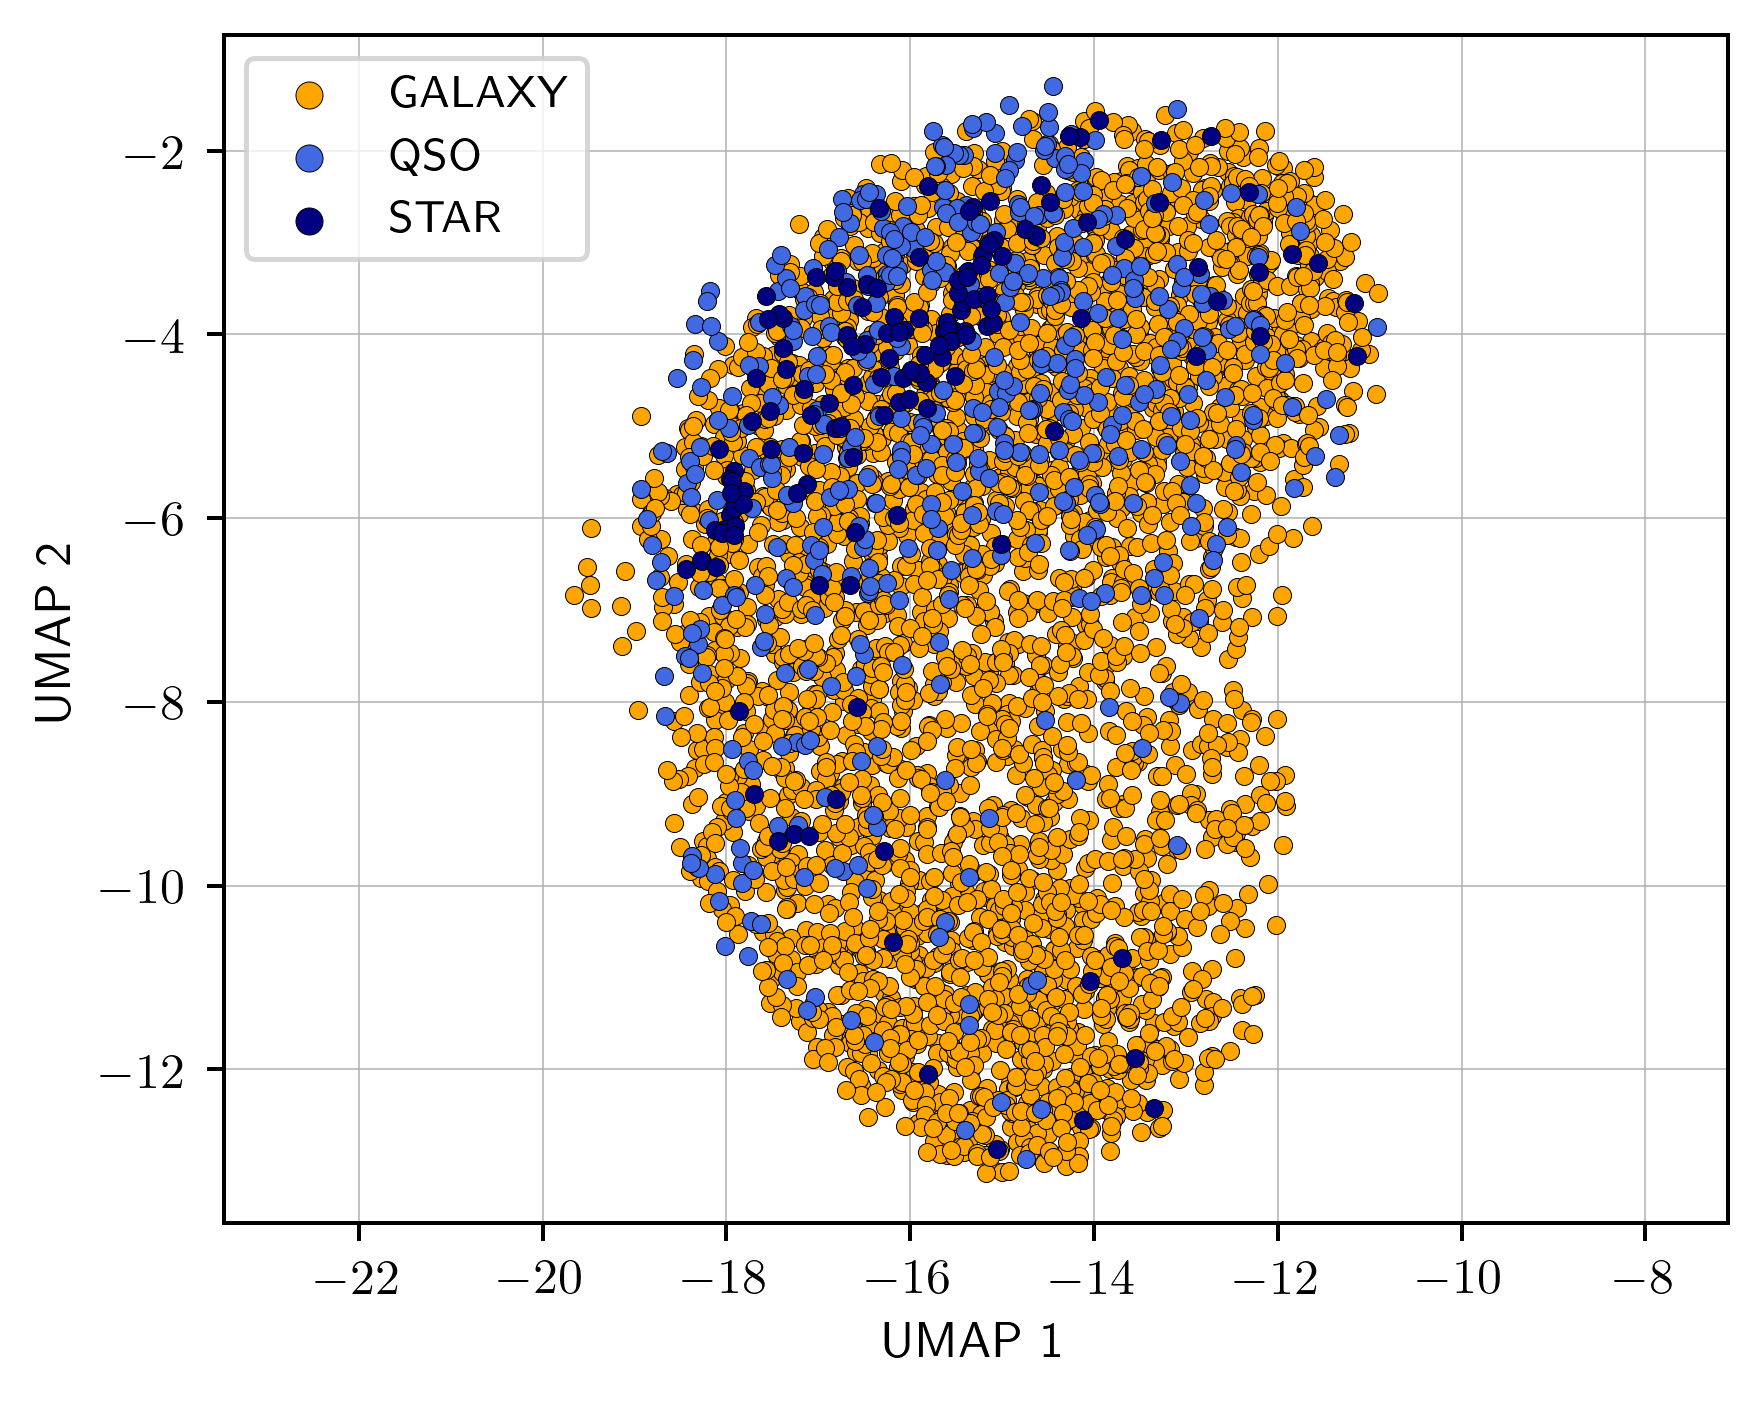

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.grid(linewidth=0.3, zorder=-1)
ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

for cat in uniq_cats:
    c = next(color_cycle)
    m = (categories == cat)
    if np.any(m):
        ax.scatter(embedding[m, 0], embedding[m, 1],
                   s=13, linewidths=0.2, edgecolor='black',
                   color=c, label=str(cat), zorder=2, alpha=1.0)
        
plt.legend(loc='upper left', frameon=True, fontsize=9, markerscale=1.5)
plt.tight_layout()
plt.savefig('fig2.png', dpi=360)
plt.show()

In [ ]:
link_length = 1.0
min_cluster_size = 5

clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                            min_samples=1,
                            cluster_selection_epsilon=link_length,
                            metric='euclidean')

labels = clusterer.fit_predict(embedding)

cluster_labels = sorted([lab for lab in np.unique(labels) if lab != -1])

In [ ]:
cluster_sizes = {lab: np.sum(labels == lab) for lab in cluster_labels}

cluster_labels_sorted = sorted(cluster_labels,
                               key=lambda lab: cluster_sizes[lab],
                               reverse=True)

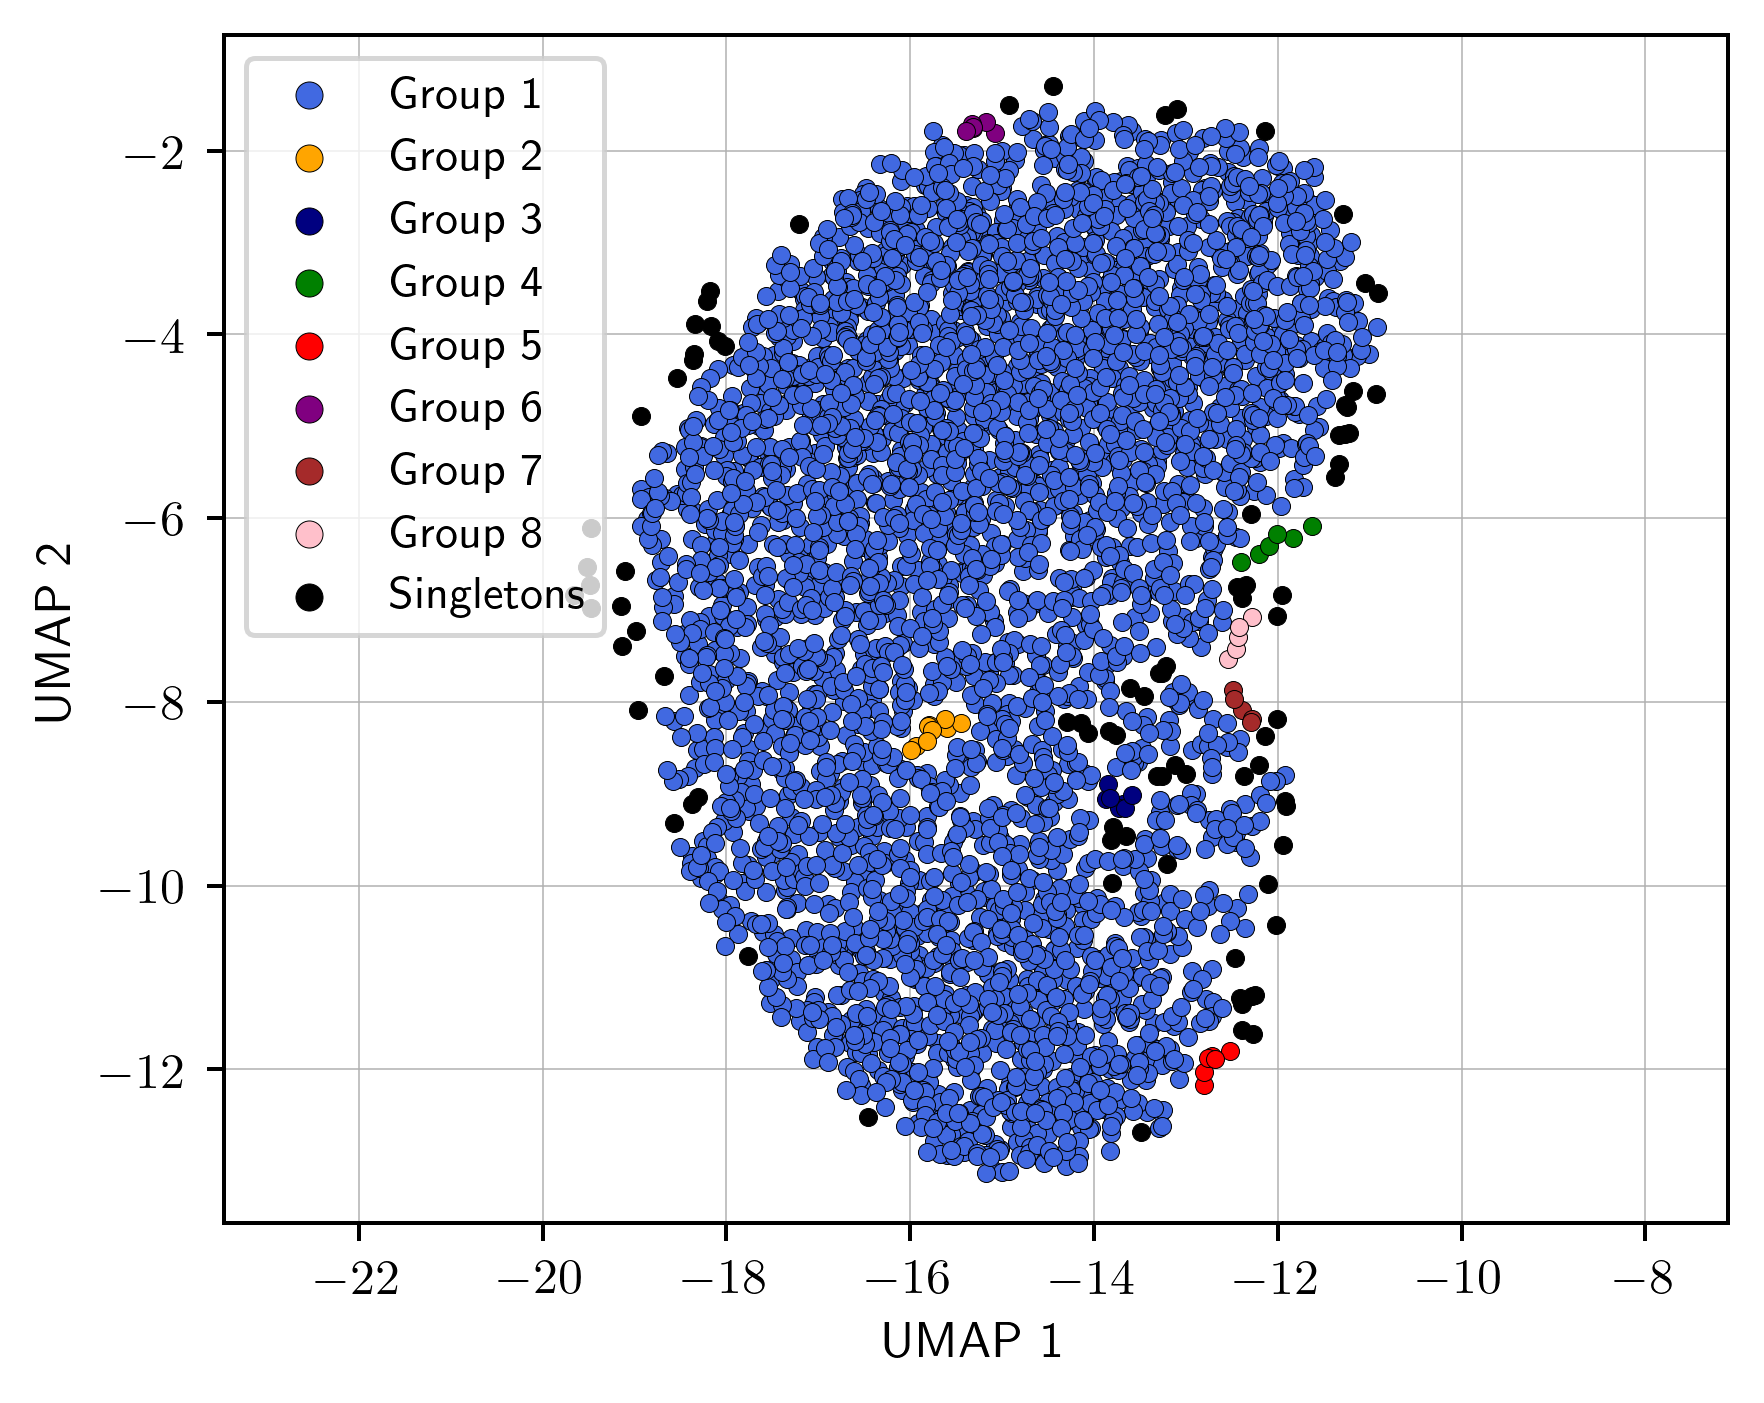

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.grid(linewidth=0.3, zorder=-1)
ax.set_aspect('equal', adjustable='datalim')

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

base_colors = ['royalblue',
               'orange',
               'navy',
               'green',
               'red',
               'purple',
               'brown',
               'pink']

color_cycle = cycle(base_colors)

for i, lab in enumerate(cluster_labels_sorted, start=1):
    m = labels == lab
    c = next(color_cycle)

    ax.scatter(embedding[m, 0],
               embedding[m, 1],
               s=13,
               linewidths=0.2,
               edgecolor='black',
               color=c,
               label=f'Group {i}',
               zorder=2,
               alpha=1.0)

singleton_mask = labels == -1

ax.scatter(embedding[singleton_mask, 0],
           embedding[singleton_mask, 1],
           s=13,
           linewidths=0.2,
           edgecolor='black',
           color='black',
           label='Singletons',
           zorder=3,
           alpha=1.0)

ax.legend(loc='upper left',
          frameon=True,
          fontsize=9,
          markerscale=1.5)

plt.tight_layout()
plt.savefig('fig3.png', dpi=360)
plt.show()

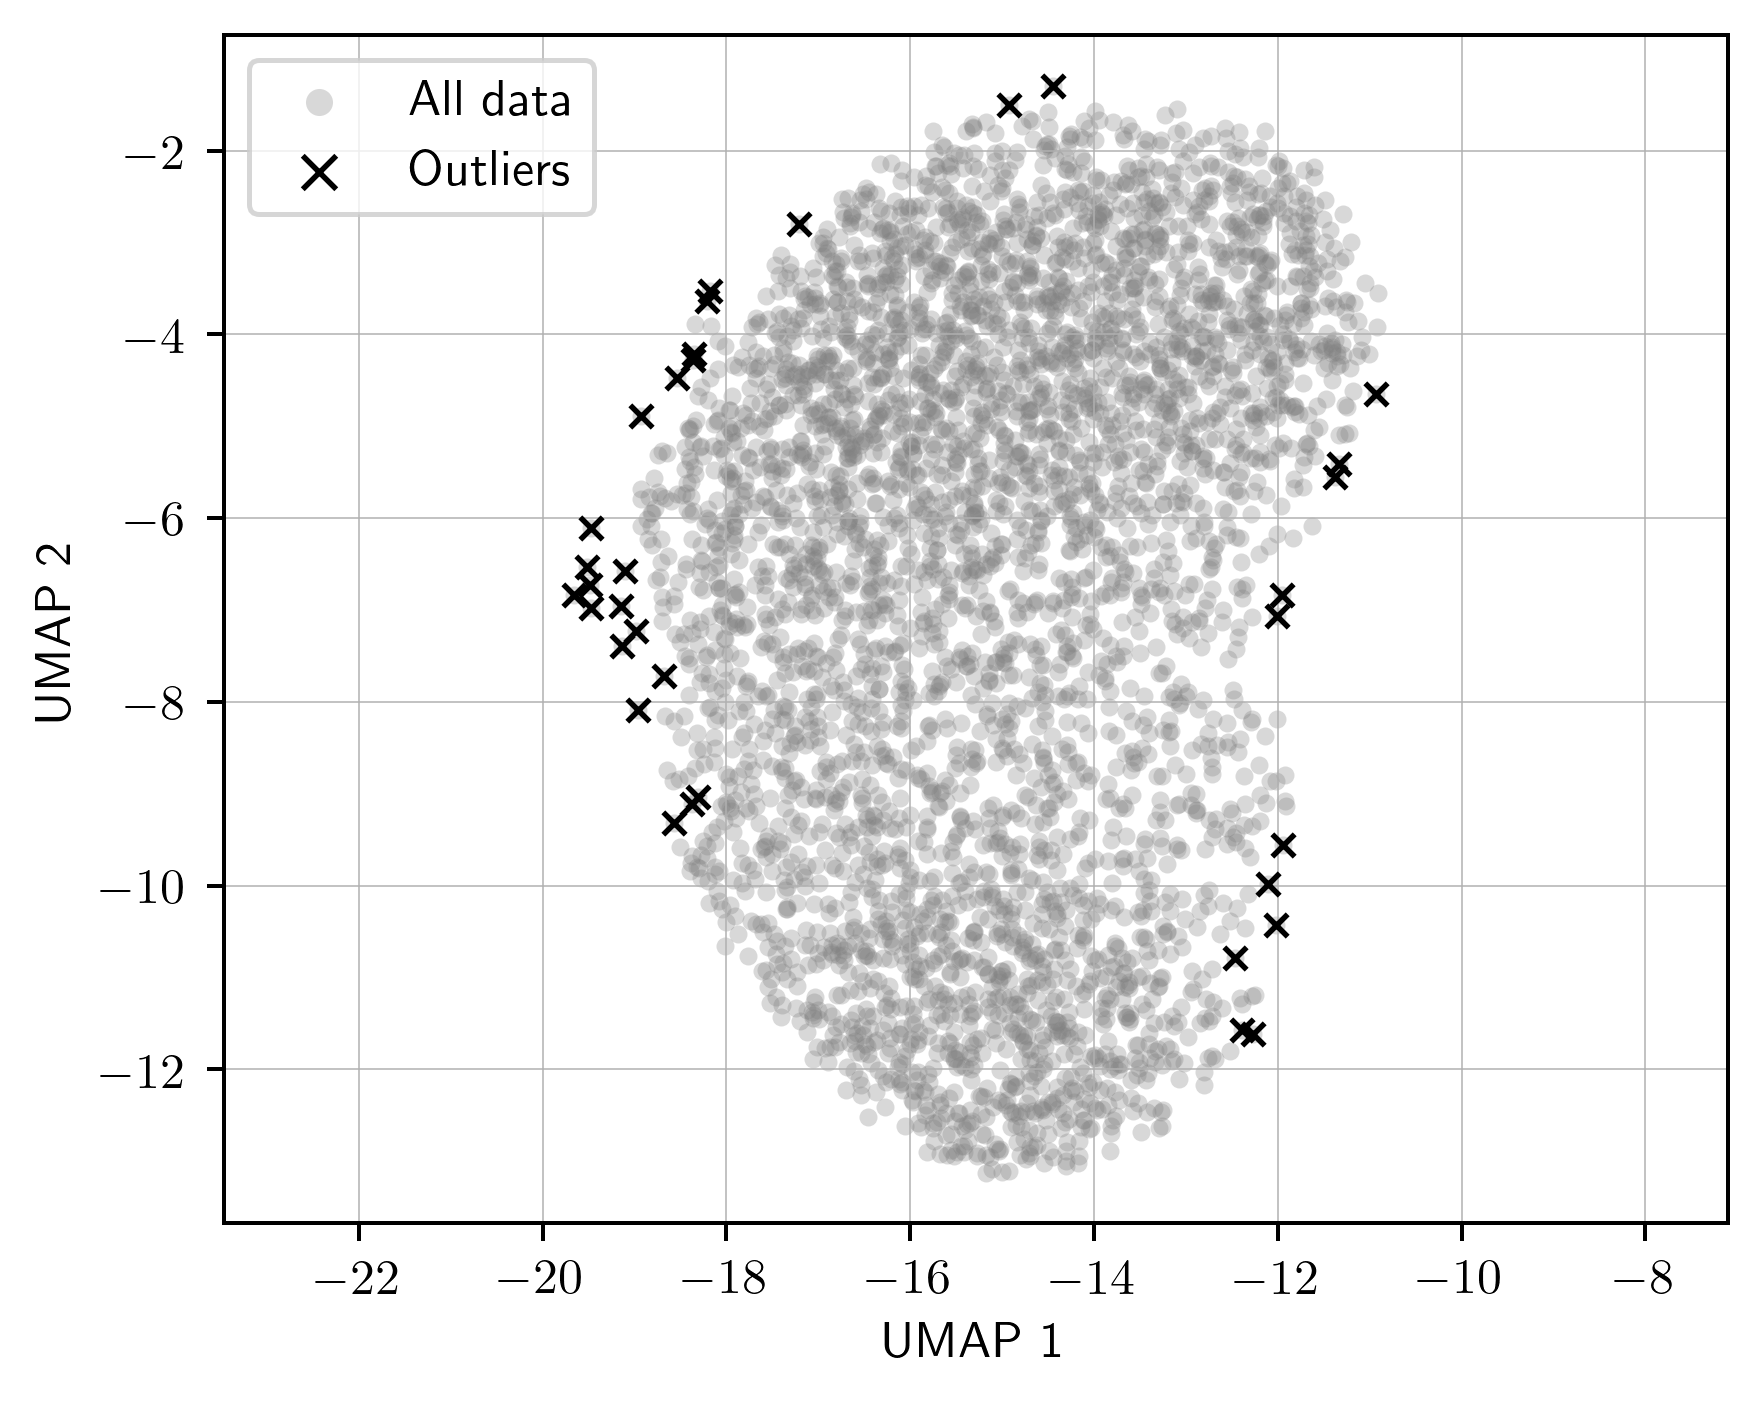

In [ ]:
outlier_mask = outlier_mask.astype(bool)

fig, ax = plt.subplots(figsize=(5, 4))

ax.grid(linewidth=0.3, zorder=-1)
ax.set_aspect('equal', adjustable='datalim')

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

ax.scatter(embedding[:, 0],
           embedding[:, 1],
           s=13,
           color='gray',
           alpha=0.3,
           linewidths=0,
           label='All data',
           zorder=1)

ax.scatter(embedding[outlier_mask, 0],
           embedding[outlier_mask, 1],
           s=20,
           color='black',
           marker='x',
           linewidths=1.1,
           label='Outliers',
           zorder=3)

ax.legend(loc='upper left',
          frameon=True,
          fontsize=10,
          markerscale=1.5)

plt.tight_layout()
plt.savefig('fig4.png', dpi=360)
plt.show()

In [9]:
out_path = '/pscratch/sd/v/vtorresg/umap_analysis/data/loa/sum/all_outliers.csv'
df = pd.read_csv(out_path)
df

,TARGETID,TILEID,FIBER,NIGHT
0,39628488918960090,80615,7,20201216
1,39628483697050350,80615,50,20201216
2,39628483697049697,80615,63,20201216
3,39628483697053483,80615,89,20201216
4,39628494136674203,80615,298,20201216
...,...,...,...,...
1095811,39628130062703971,9203,4317,20240409
1095812,39628130062700740,9203,4332,20240409
1095813,39628124194869235,9203,4699,20240409
1095814,39628106578792402,9203,4814,20240409


In [ ]:
outliers_per_tile = (df.groupby('TILEID')
                     .size().reset_index(name='N_outliers'))

In [ ]:
x = outliers_per_tile['N_outliers'].values

bin_width = 10
bins = np.arange(0, x.max() + bin_width, bin_width)

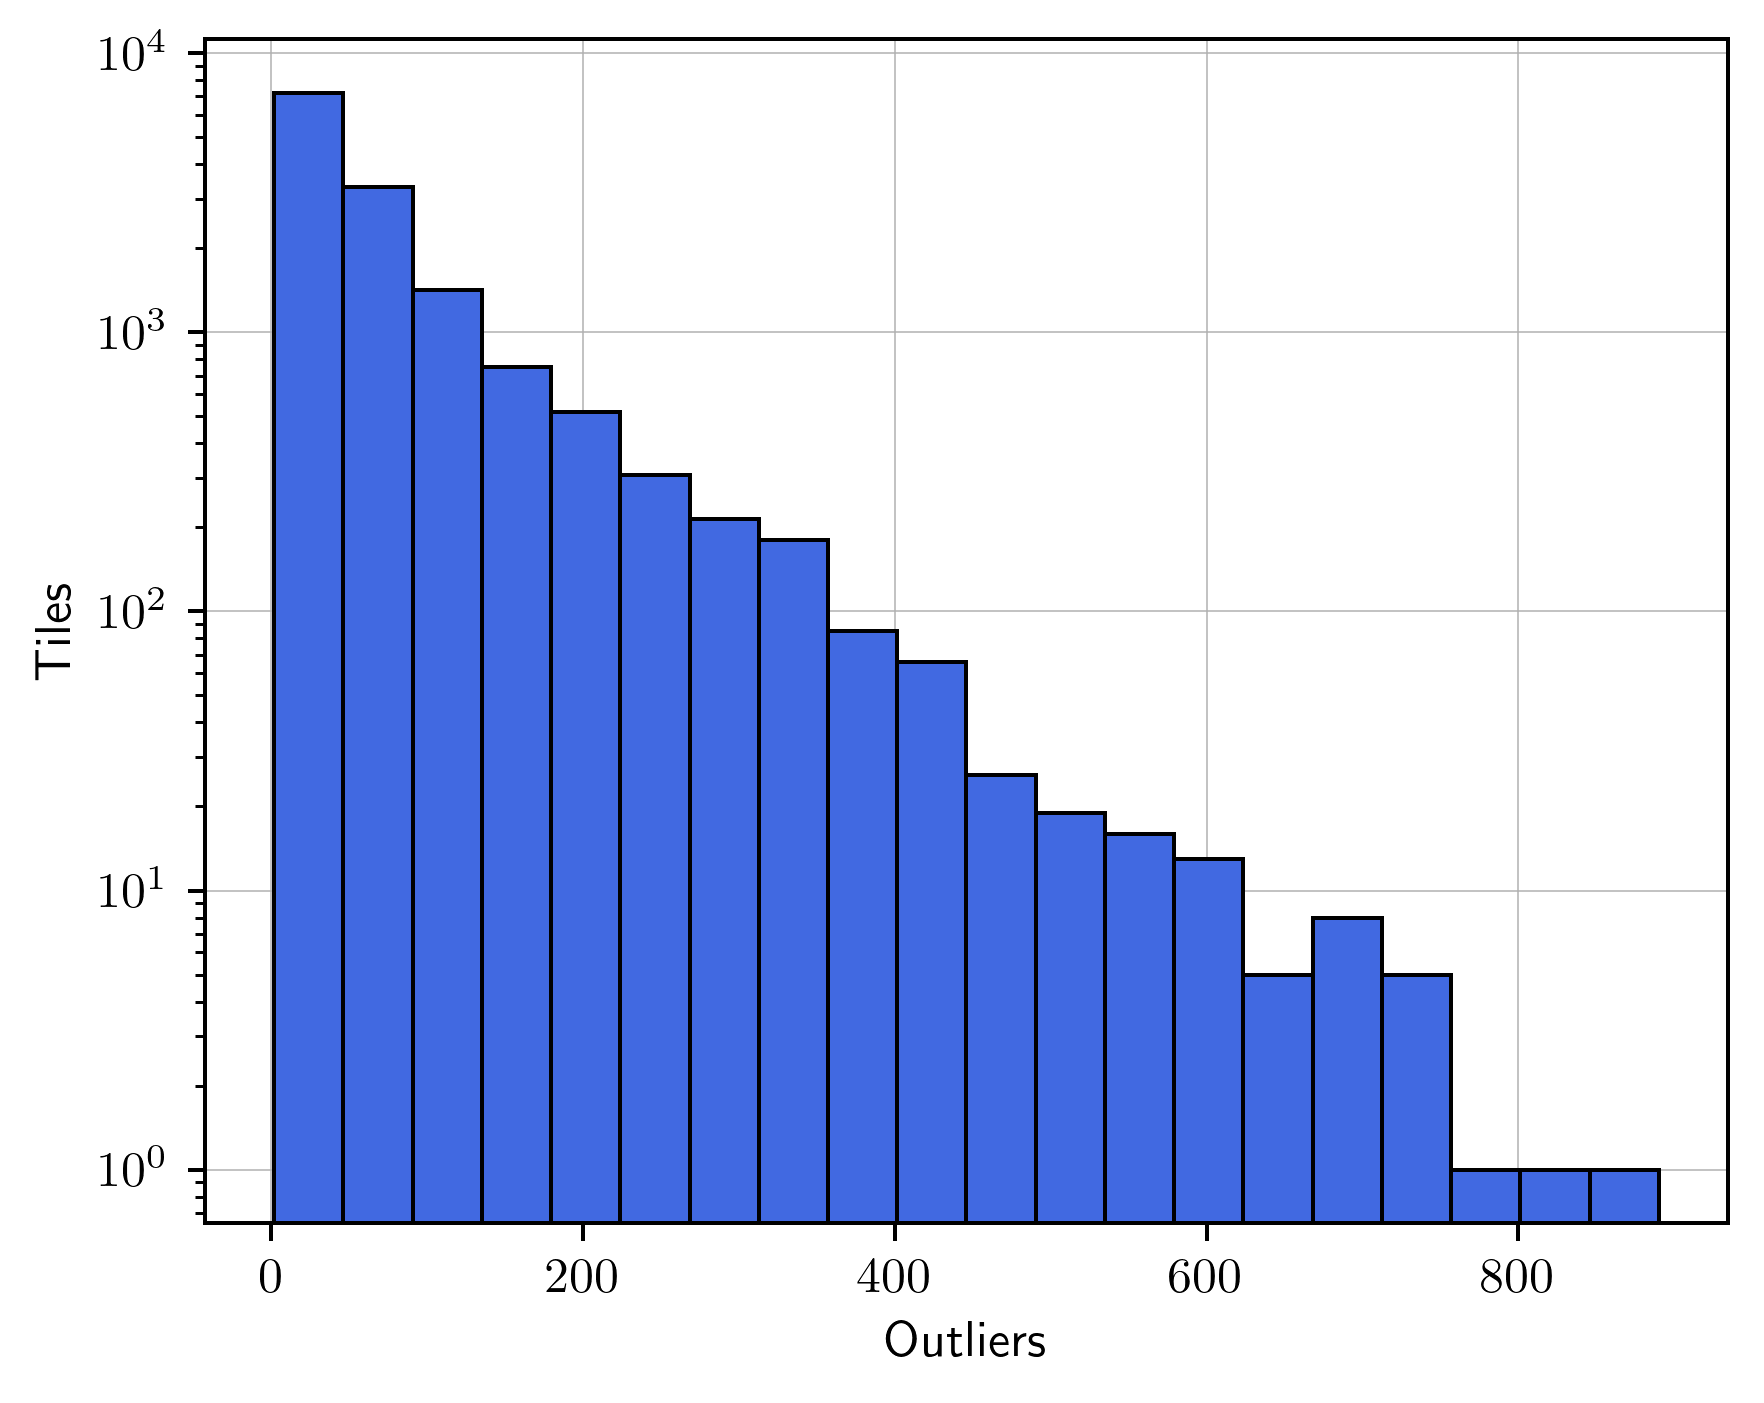

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(outliers_per_tile['N_outliers'],
    bins=20,
    color='royalblue',
    edgecolor='black',
    linewidth=0.8)

ax.grid(linewidth=0.3, zorder=-1)
ax.set_axisbelow(True)

ax.set_xlabel('Outliers')
ax.set_ylabel('Tiles')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('fig5.png', dpi=360)
plt.show()

In [ ]:
outliers_per_fiber = (df.groupby('FIBER').size().reset_index(name='N_outliers'))

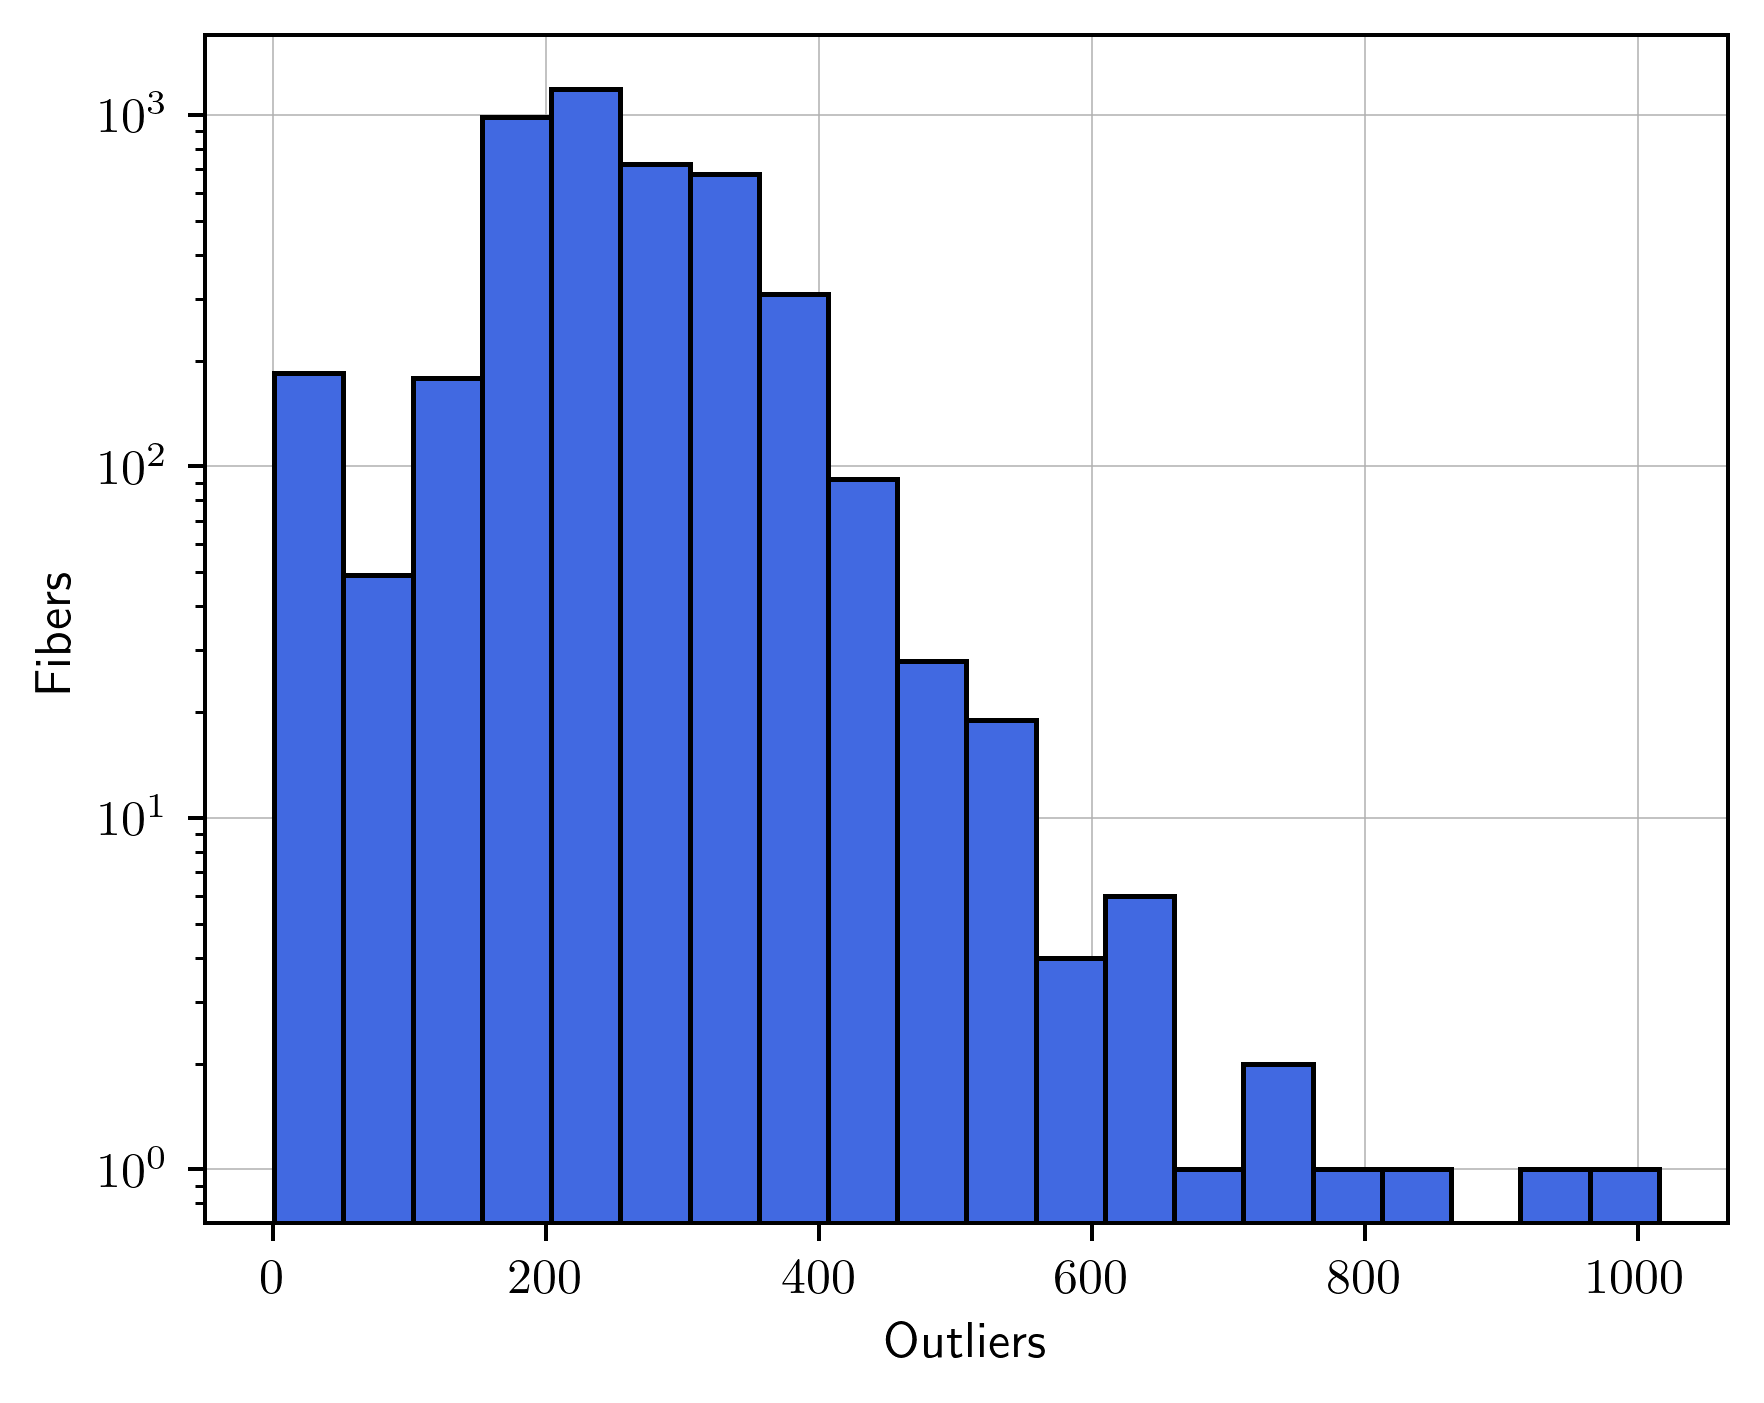

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(outliers_per_fiber['N_outliers'],
        bins=20,
        color='royalblue',
        edgecolor='black',
        linewidth=1.0,
        alpha=1.0)

ax.grid(linewidth=0.3, zorder=-1)
ax.set_axisbelow(True)

ax.set_xlabel('Outliers')
ax.set_ylabel('Fibers')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('fig6.png', dpi=360)
plt.show()

In [13]:
df_fibers = pd.read_csv('data.csv')

In [ ]:
outliers_per_fiber = (df.groupby('FIBER').size().reset_index(name='N_outliers'))

fiber_info = df_fibers[['FIBER', 'PETAL', 'MEAN_FIBER_X', 'MEAN_FIBER_Y']].drop_duplicates(subset='FIBER')

df_fiber_outliers = fiber_info.merge(outliers_per_fiber, on='FIBER', how='inner')
df_fiber_outliers

,FIBER,PETAL,MEAN_FIBER_X,MEAN_FIBER_Y,N_outliers
0,0,0,80.475,-287.498,267
1,1,0,57.113,-274.135,245
2,2,0,31.010,-274.411,237
3,3,0,2.074,-224.726,212
4,4,0,-22.823,-249.978,253
...,...,...,...,...,...
4444,4995,9,-146.077,-196.691,384
4445,4996,9,-98.808,-256.809,440
4446,4997,9,-138.929,-204.096,395
4447,4998,9,-129.372,-227.033,378


In [ ]:
vmin = 0
vmax = np.nanpercentile(df_fiber_outliers['N_outliers'], 98)
cmap = sns.color_palette('mako_r', as_cmap=True)

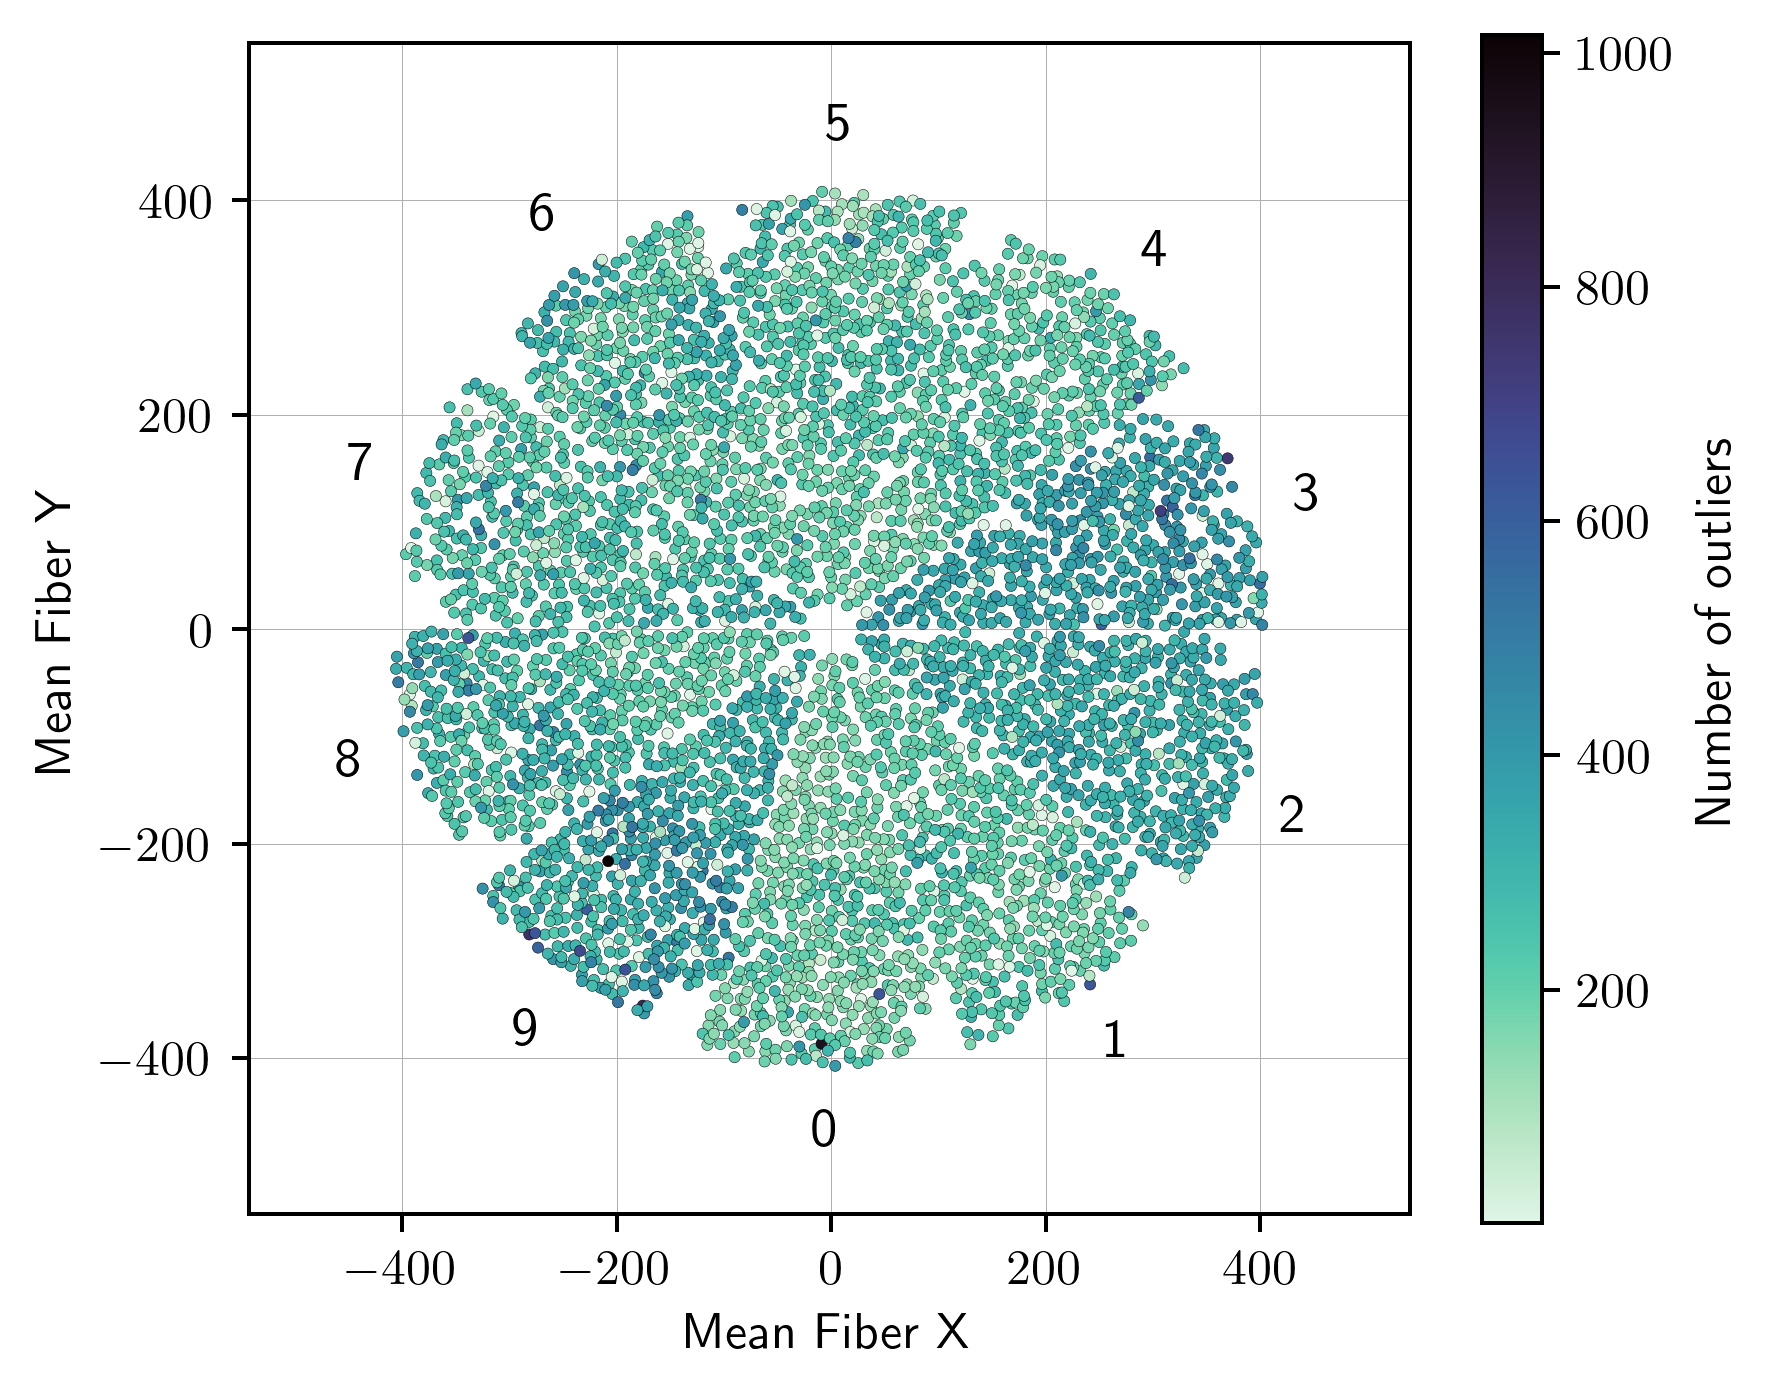

In [23]:
fig, ax = plt.subplots(figsize=(5,4))

vmin = df_fiber_outliers['N_outliers'].min()
vmax = df_fiber_outliers['N_outliers'].max()
log_norm = colors.LogNorm(vmin=vmin, vmax=vmax)

sc = ax.scatter(df_fiber_outliers['MEAN_FIBER_X'], df_fiber_outliers['MEAN_FIBER_Y'],
                s=5, c=df_fiber_outliers['N_outliers'], cmap=cmap, zorder=10,#norm=log_norm,
                edgecolor='black', linewidth=0.1,
                vmin=vmin, vmax=vmax)
for petal, grp in df_fiber_outliers.groupby('PETAL'):
    x_c = grp['MEAN_FIBER_X'].mean()
    y_c = grp['MEAN_FIBER_Y'].mean()
    d = np.sqrt((df_fiber_outliers['MEAN_FIBER_X'] - x_c)**2 + (df_fiber_outliers['MEAN_FIBER_Y'] - y_c)**2)
    edge_x, edge_y = df_fiber_outliers['MEAN_FIBER_X'][np.argmax(d)], df_fiber_outliers['MEAN_FIBER_Y'][np.argmax(d)]
    ax.text(x_c - 0.3 * (edge_x - x_c), y_c - 0.3 * (edge_y - y_c),
        str(petal), fontweight='bold', color='black',
        ha='center', va='center', zorder=100, fontsize=11)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Number of outliers')

ax.set_aspect('equal')
ax.tick_params(axis='both', which='major')
ax.margins(x=0.17, y=0.17)
ax.set_xlabel('Mean Fiber X')
ax.set_ylabel('Mean Fiber Y')

plt.grid(linewidth=0.2, zorder=0)
plt.tight_layout()
plt.savefig('fig7.png', dpi=360)
plt.show()

In [16]:
df_fiber_outliers

,FIBER,PETAL,MEAN_FIBER_X,MEAN_FIBER_Y,N_outliers
0,0,0,80.475,-287.498,267
1,1,0,57.113,-274.135,245
2,2,0,31.010,-274.411,237
3,3,0,2.074,-224.726,212
4,4,0,-22.823,-249.978,253
...,...,...,...,...,...
4444,4995,9,-146.077,-196.691,384
4445,4996,9,-98.808,-256.809,440
4446,4997,9,-138.929,-204.096,395
4447,4998,9,-129.372,-227.033,378


In [ ]:
fiber_info = df_fibers[['FIBER', 'PETAL', 'MEAN_FIBER_X', 'MEAN_FIBER_Y']]

df2 = fiber_info.merge(df, on='FIBER', how='inner')
df2

,FIBER,PETAL,MEAN_FIBER_X,MEAN_FIBER_Y,TARGETID,TILEID,NIGHT
0,0,0,80.475,-287.498,39627629048894485,80612,20201223
1,0,0,80.475,-287.498,39633332257949250,81069,20210401
2,0,0,80.475,-287.498,39632946285513693,191,20210408
3,0,0,80.475,-287.498,1070137633406992,15,20210412
4,0,0,80.475,-287.498,39627818581099418,284,20210414
...,...,...,...,...,...,...,...
1095811,4999,9,-164.051,-199.735,39628170088943038,2102,20240403
1095812,4999,9,-164.051,-199.735,2305843017832994772,40279,20240407
1095813,4999,9,-164.051,-199.735,39628111049921259,6147,20240407
1095814,4999,9,-164.051,-199.735,39627771814615418,27153,20240409


In [ ]:
outliers_per_petal = (df2.groupby('PETAL').size().reset_index(name='N_outliers'))
outliers_per_petal

,PETAL,N_outliers
0,0,83681
1,1,85464
2,2,139846
3,3,147412
4,4,90080
5,5,94451
6,6,104312
7,7,95463
8,8,108813
9,9,146294


In [ ]:
all_petals = np.arange(10)

outliers_per_petal = (outliers_per_petal.set_index('PETAL')
                      .reindex(all_petals, fill_value=0)
                      .reset_index().rename(columns={'index': 'PETAL'}))

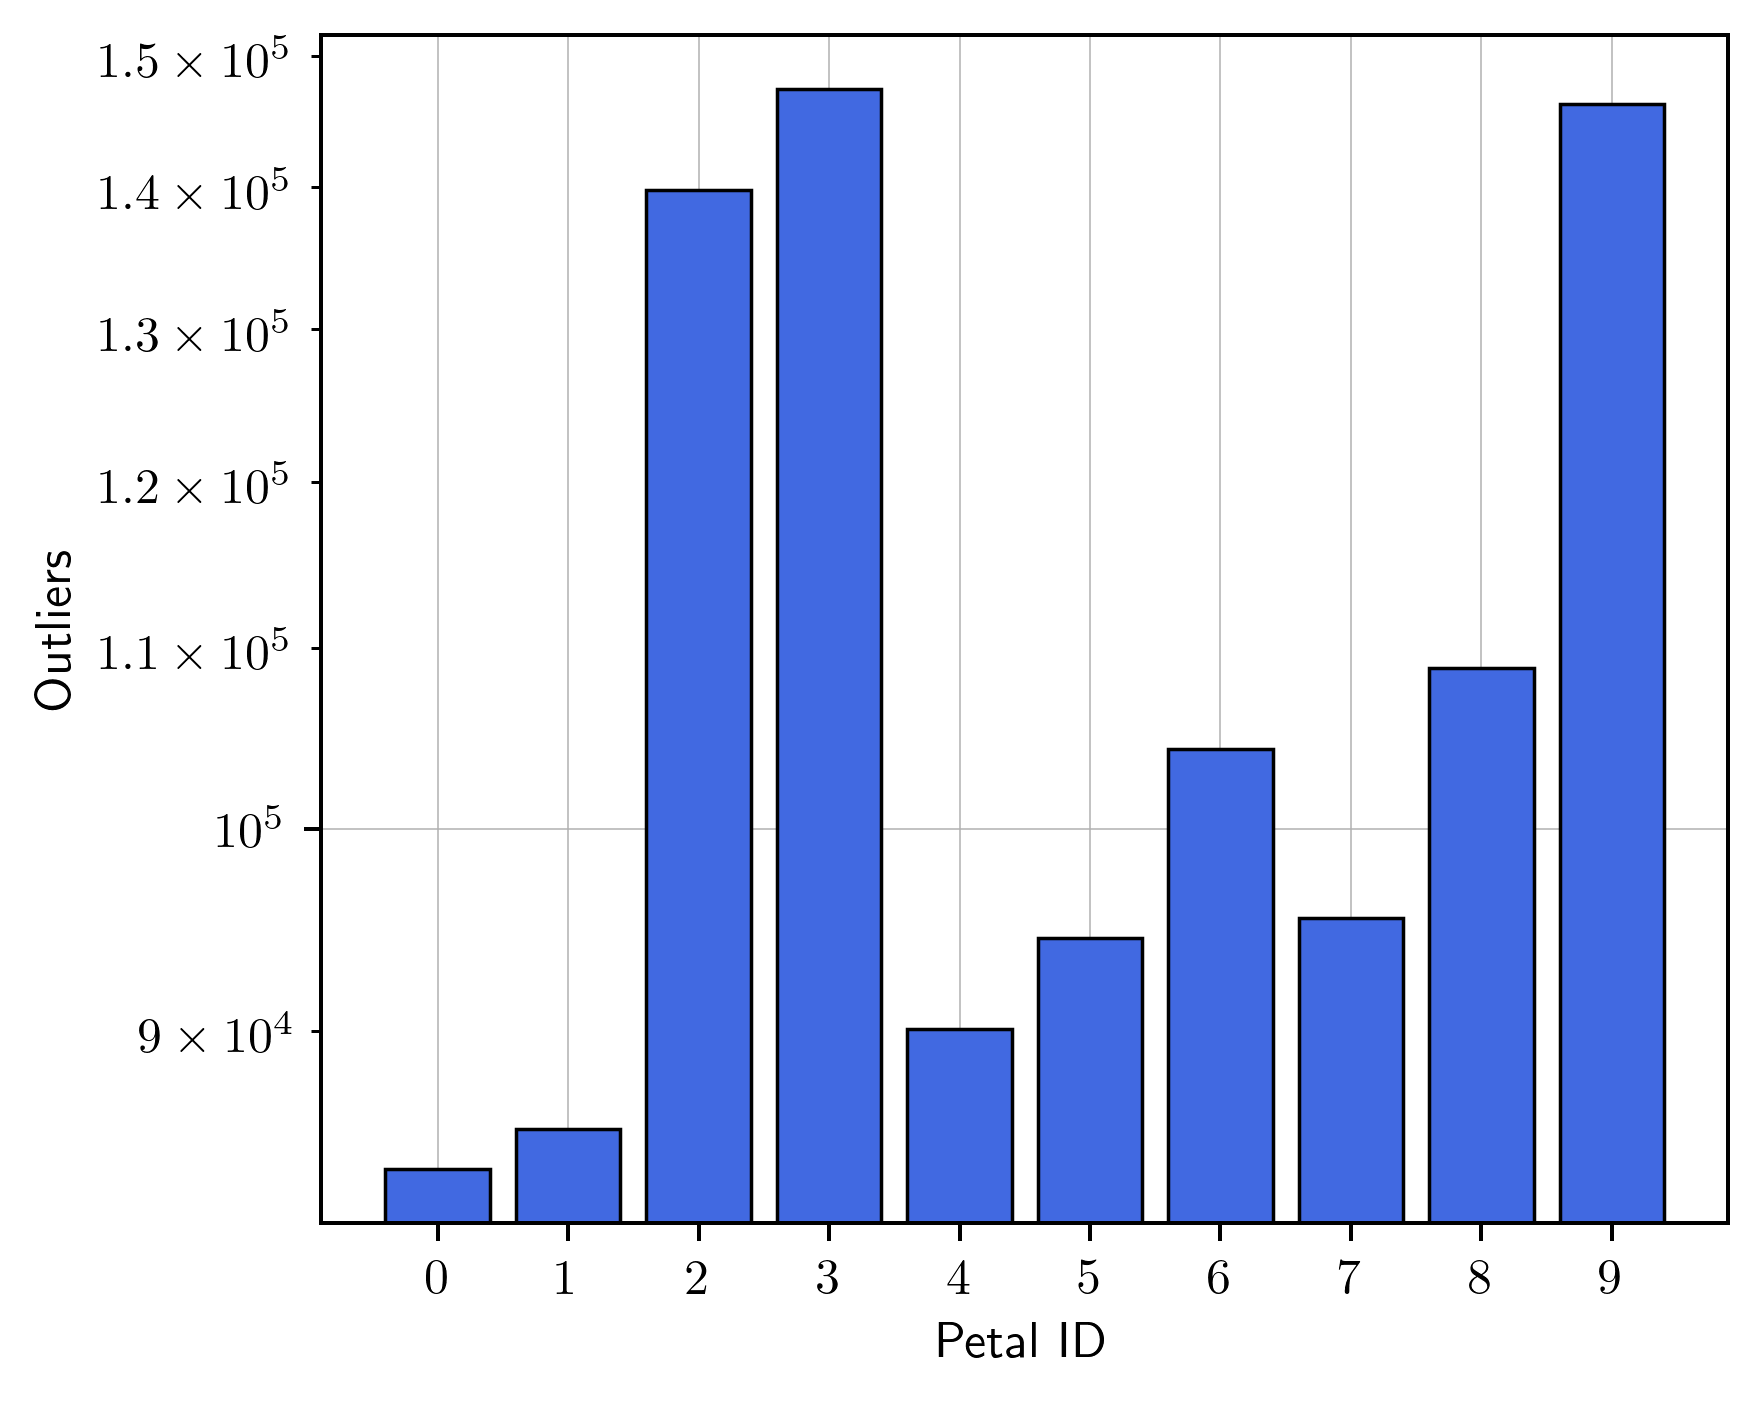

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(outliers_per_petal['PETAL'],
       outliers_per_petal['N_outliers'],
       color='royalblue',
       edgecolor='black',
       linewidth=0.7)

ax.grid(linewidth=0.3, zorder=-1)
ax.set_axisbelow(True)

ax.set_xlabel('Petal ID')
ax.set_ylabel('Outliers')

ax.set_xticks(all_petals)

plt.tight_layout()
plt.savefig('fig8.png', dpi=360)
plt.show()

In [ ]:
outliers_per_fiber = (df.groupby('FIBER').size().reset_index(name='N_outliers'))

In [ ]:
all_fibers = pd.DataFrame({'FIBER': np.arange(5000)})

outliers_per_fiber = (all_fibers
                      .merge(outliers_per_fiber, on='FIBER', how='left')
                      .fillna({'N_outliers': 0}))

In [ ]:
outliers_per_fiber['N_outliers'] = outliers_per_fiber['N_outliers'].astype(int)

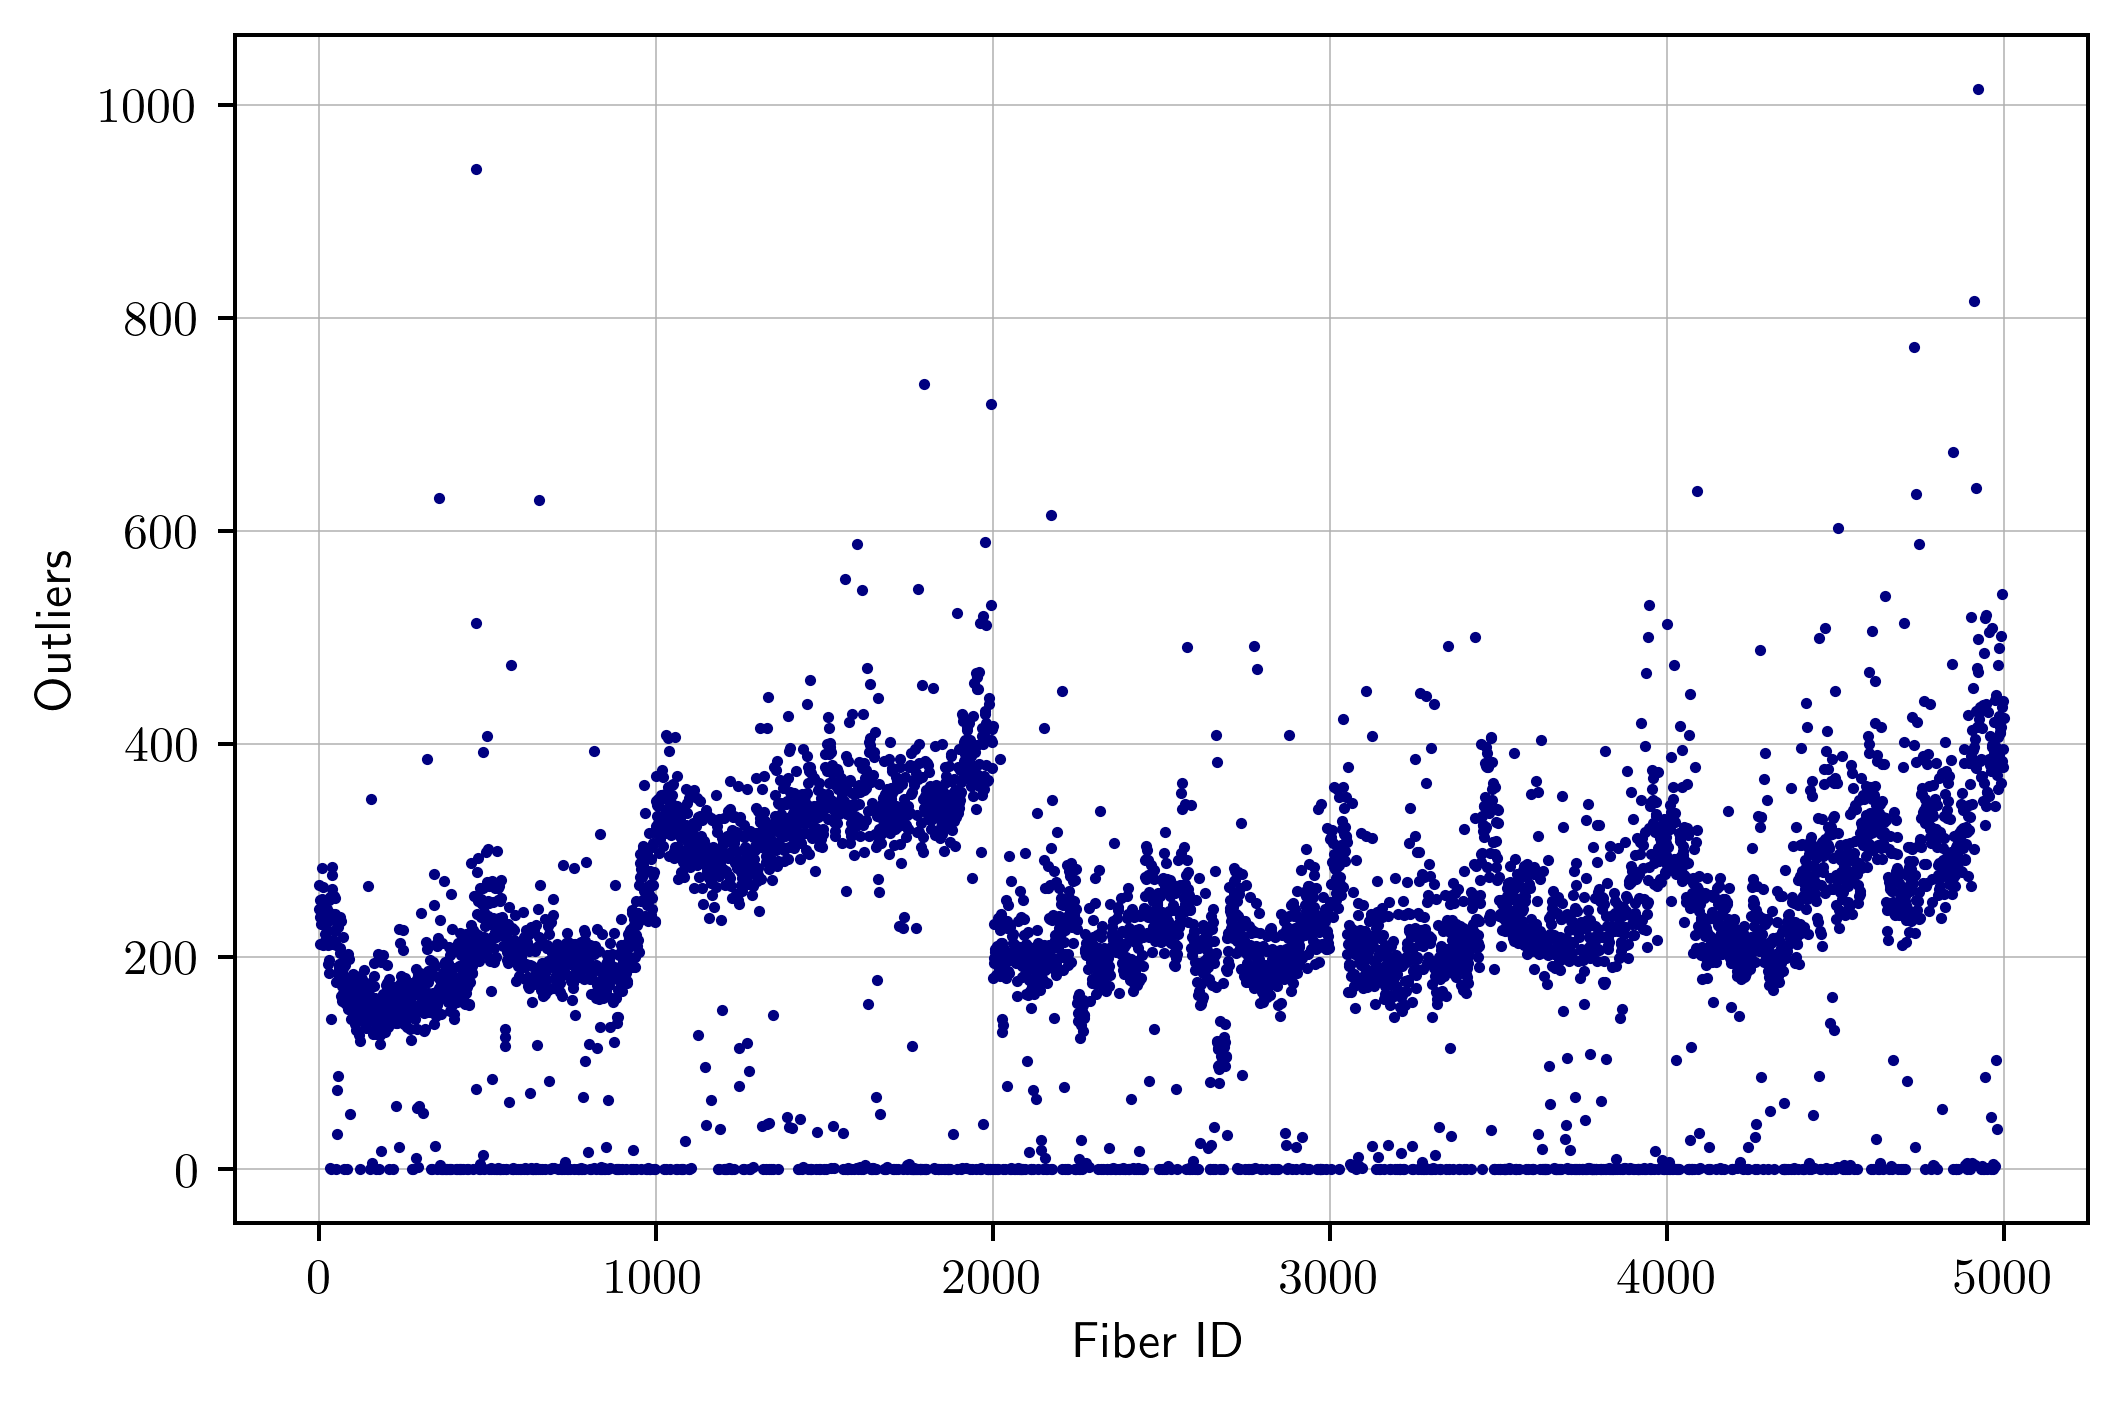

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(outliers_per_fiber['FIBER'],
    outliers_per_fiber['N_outliers'],
    s=5,
    color='navy',
    linewidths=0,
    alpha=1.0)

ax.grid(linewidth=0.3, zorder=-1)
ax.set_axisbelow(True)

ax.set_xlabel('Fiber ID')
ax.set_ylabel('Outliers')

plt.tight_layout()
plt.savefig('out_fiberid.png', dpi=360)
plt.show()

In [ ]:
log_dir = '/pscratch/sd/v/vtorresg/umap_analysis/data/loa/data/logs/'
log_files = sorted(glob.glob(os.path.join(log_dir, '*.out')))

In [ ]:
rows = []

for logfile in log_files:
    with open(logfile, 'r') as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if line.upper().startswith('NIGHT'):
                continue

            parts = line.replace(',', ' ').split()

            if len(parts) < 3:
                continue

            try:
                night = int(parts[0])
                tile = int(parts[1])
                time = float(parts[2])
            except ValueError:
                continue

            rows.append({'NIGHT': night,
                         'TILEID': tile,
                         'TIME': time,
                         'logfile': os.path.basename(logfile)})

In [25]:
df_times = pd.DataFrame(rows)
df_times

,NIGHT,TILEID,TIME,logfile
0,20210406,1,81.1,1.out
1,20210503,10,80.4,10.out
2,20210505,100,63.1,100.out
3,20210517,1000,93.6,1000.out
4,20220421,10001,57.3,10001.out
...,...,...,...,...
14155,20230417,9988,67.9,9988.out
14156,20240407,9989,104.4,9989.out
14157,20220401,9992,57.0,9992.out
14158,20230527,9994,67.7,9994.out


In [26]:
df_times_ = df_times[df_times['TIME']<200]

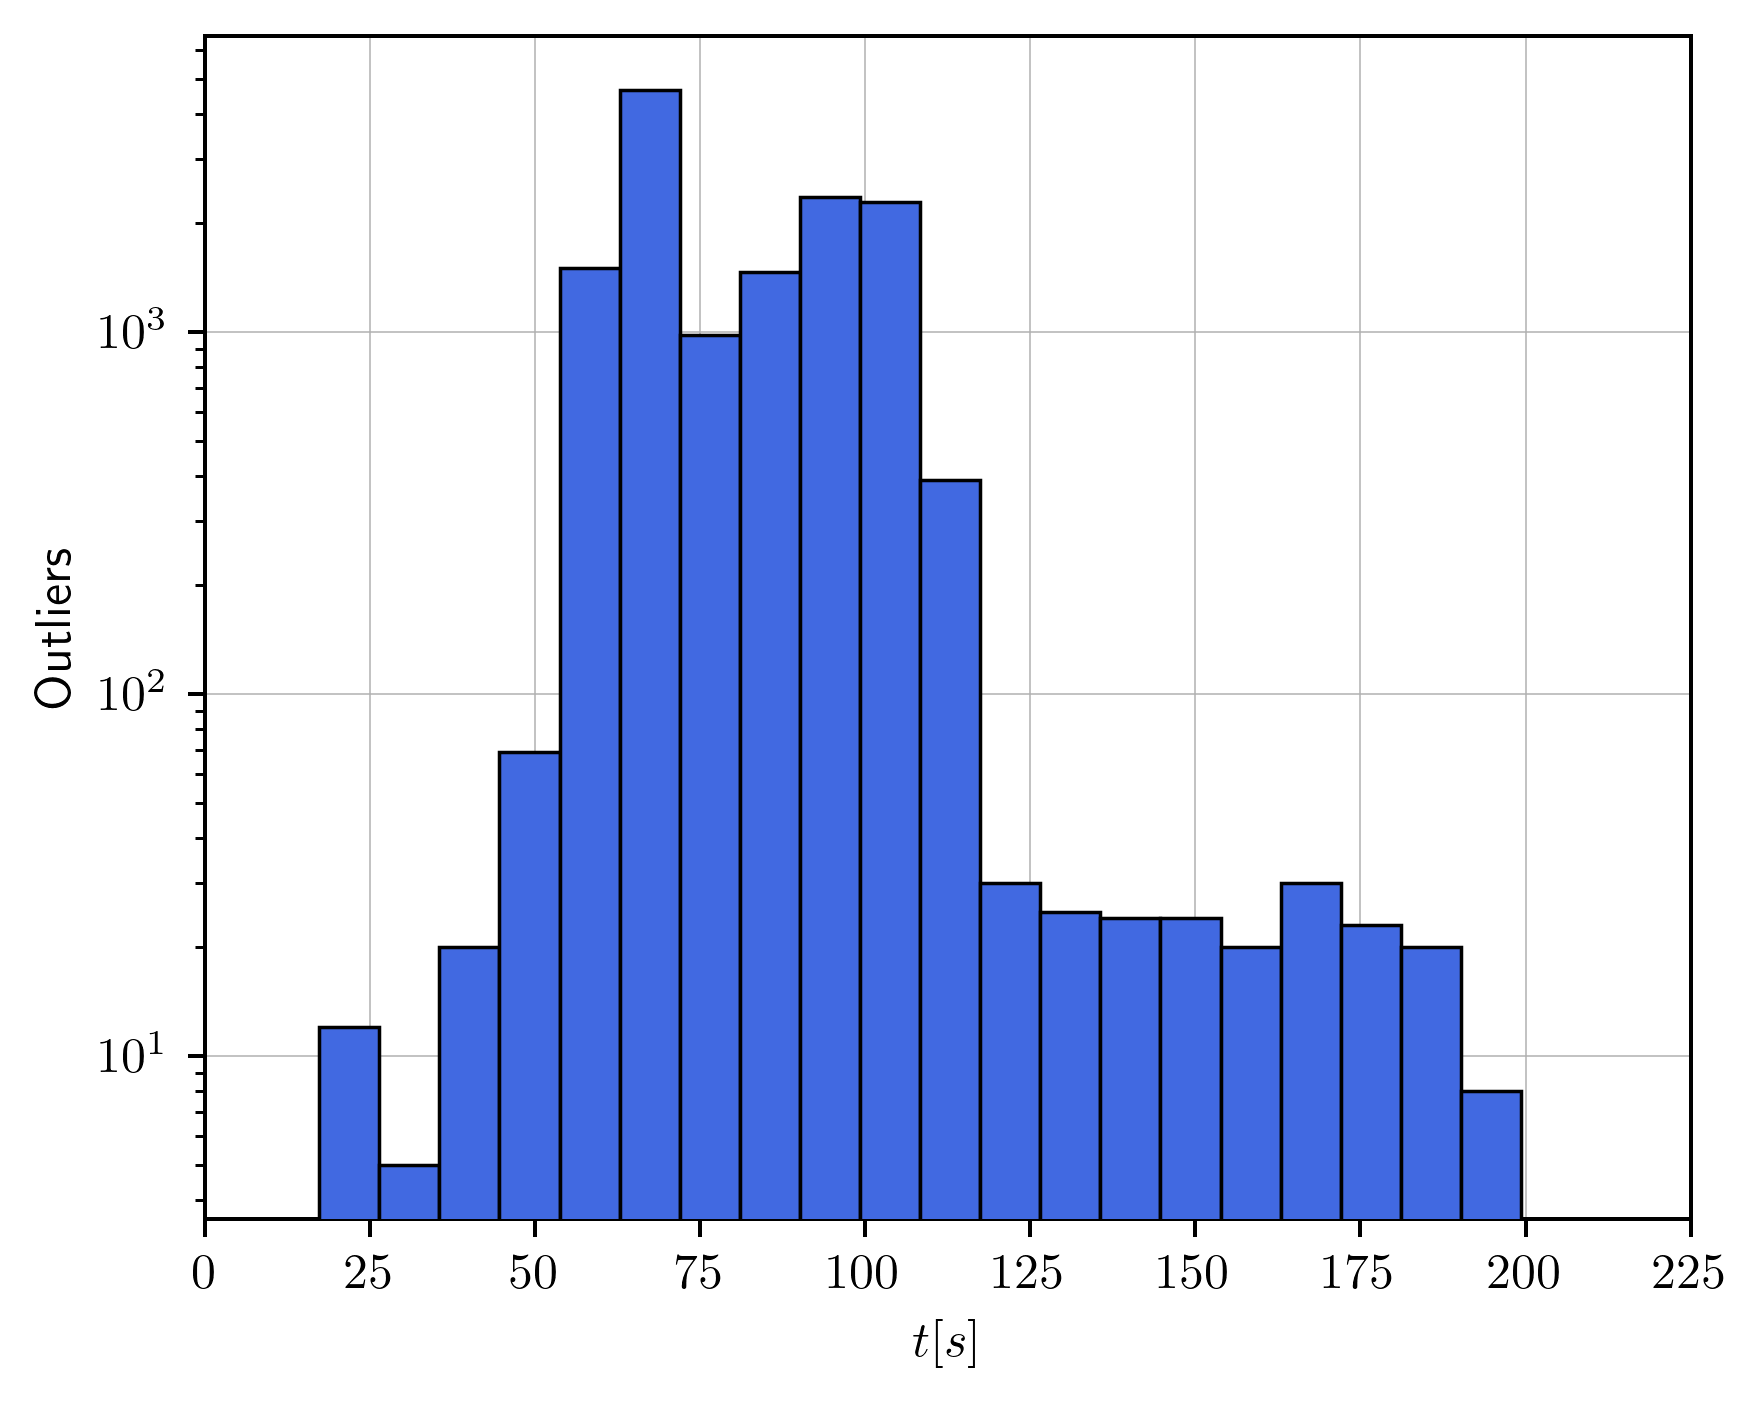

In [ ]:
count = df_times_['TIME'].value_counts().sort_index()
valores = np.repeat(count.index.values, count.values)

fig, ax = plt.subplots(figsize=(5, 4))
n_bins = 20

plt.grid(linewidth=0.3, zorder=-1)
ax.hist(valores, bins=n_bins, color='royalblue', edgecolor='black', 
        linewidth=0.7, zorder=3)

ax.set_xlabel(r'$t [s]$')
ax.set_ylabel('Outliers')

bin_edges = ax.get_xticks()
k = max(1, len(bin_edges) // 10)
ticks = bin_edges[::k]
ax.set_xticks(ticks)
ax.set_xticklabels([f'${int(t)}$' for t in ticks])
ax.set_yscale('log')
# plt.title('Processing Times')

plt.tight_layout()
plt.savefig('times.png', dpi=360)
plt.show()

In [27]:
dfr = pd.read_csv('/pscratch/sd/v/vtorresg/umap_analysis/data/loa/sum/outlier_redrock_zwarn_spectype_subtype.csv')
dfr

,TARGETID,TILEID,FIBER,NIGHT,PETAL,ZWARN,SPECTYPE,SUBTYPE
0,39628488918960090,80615,7,20201216,0,0,GALAXY,NaN
1,39628483697050350,80615,50,20201216,0,0,GALAXY,NaN
2,39628483697049697,80615,63,20201216,0,0,GALAXY,NaN
3,39628483697053483,80615,89,20201216,0,0,GALAXY,NaN
4,39628494136674203,80615,298,20201216,0,0,STAR,K
...,...,...,...,...,...,...,...,...
1095811,39628130062703971,9203,4317,20240409,8,4,GALAXY,NaN
1095812,39628130062700740,9203,4332,20240409,8,0,GALAXY,NaN
1095813,39628124194869235,9203,4699,20240409,9,4,GALAXY,NaN
1095814,39628106578792402,9203,4814,20240409,9,0,GALAXY,NaN


In [25]:
from desitarget.targetmask import zwarn_mask

In [ ]:
def get_zwarn_flags(zwarn_value):
    flags = []

    for name in zwarn_mask.names():
        if (zwarn_value & zwarn_mask[name]) != 0:
            flags.append(name)

    if len(flags) == 0:
        return 'OK'

    return ','.join(flags)

In [ ]:
dfr['ZWARN_FLAGS'] = [get_zwarn_flags(z)
                     for z in dfr['ZWARN'].values]

In [32]:
np.unique(dfr['ZWARN_FLAGS'])

array(['OK', 'SMALL_DELTA_CHI2'], dtype=object)

In [ ]:
zwarn_counts = (dfr['ZWARN_FLAGS']
                .value_counts()
                .rename_axis('ZWARN_FLAGS')
                .reset_index(name='Counts'))

In [ ]:
label_map = {'OK': 'None',
             'SMALL_DELTA_CHI2': r'Small $\Delta\chi^2$',}

In [ ]:
zwarn_counts['label'] = zwarn_counts['ZWARN_FLAGS'].map(label_map).fillna(
    zwarn_counts['ZWARN_FLAGS'])

In [ ]:
labels = zwarn_counts['label'].values
counts = zwarn_counts['Counts'].values

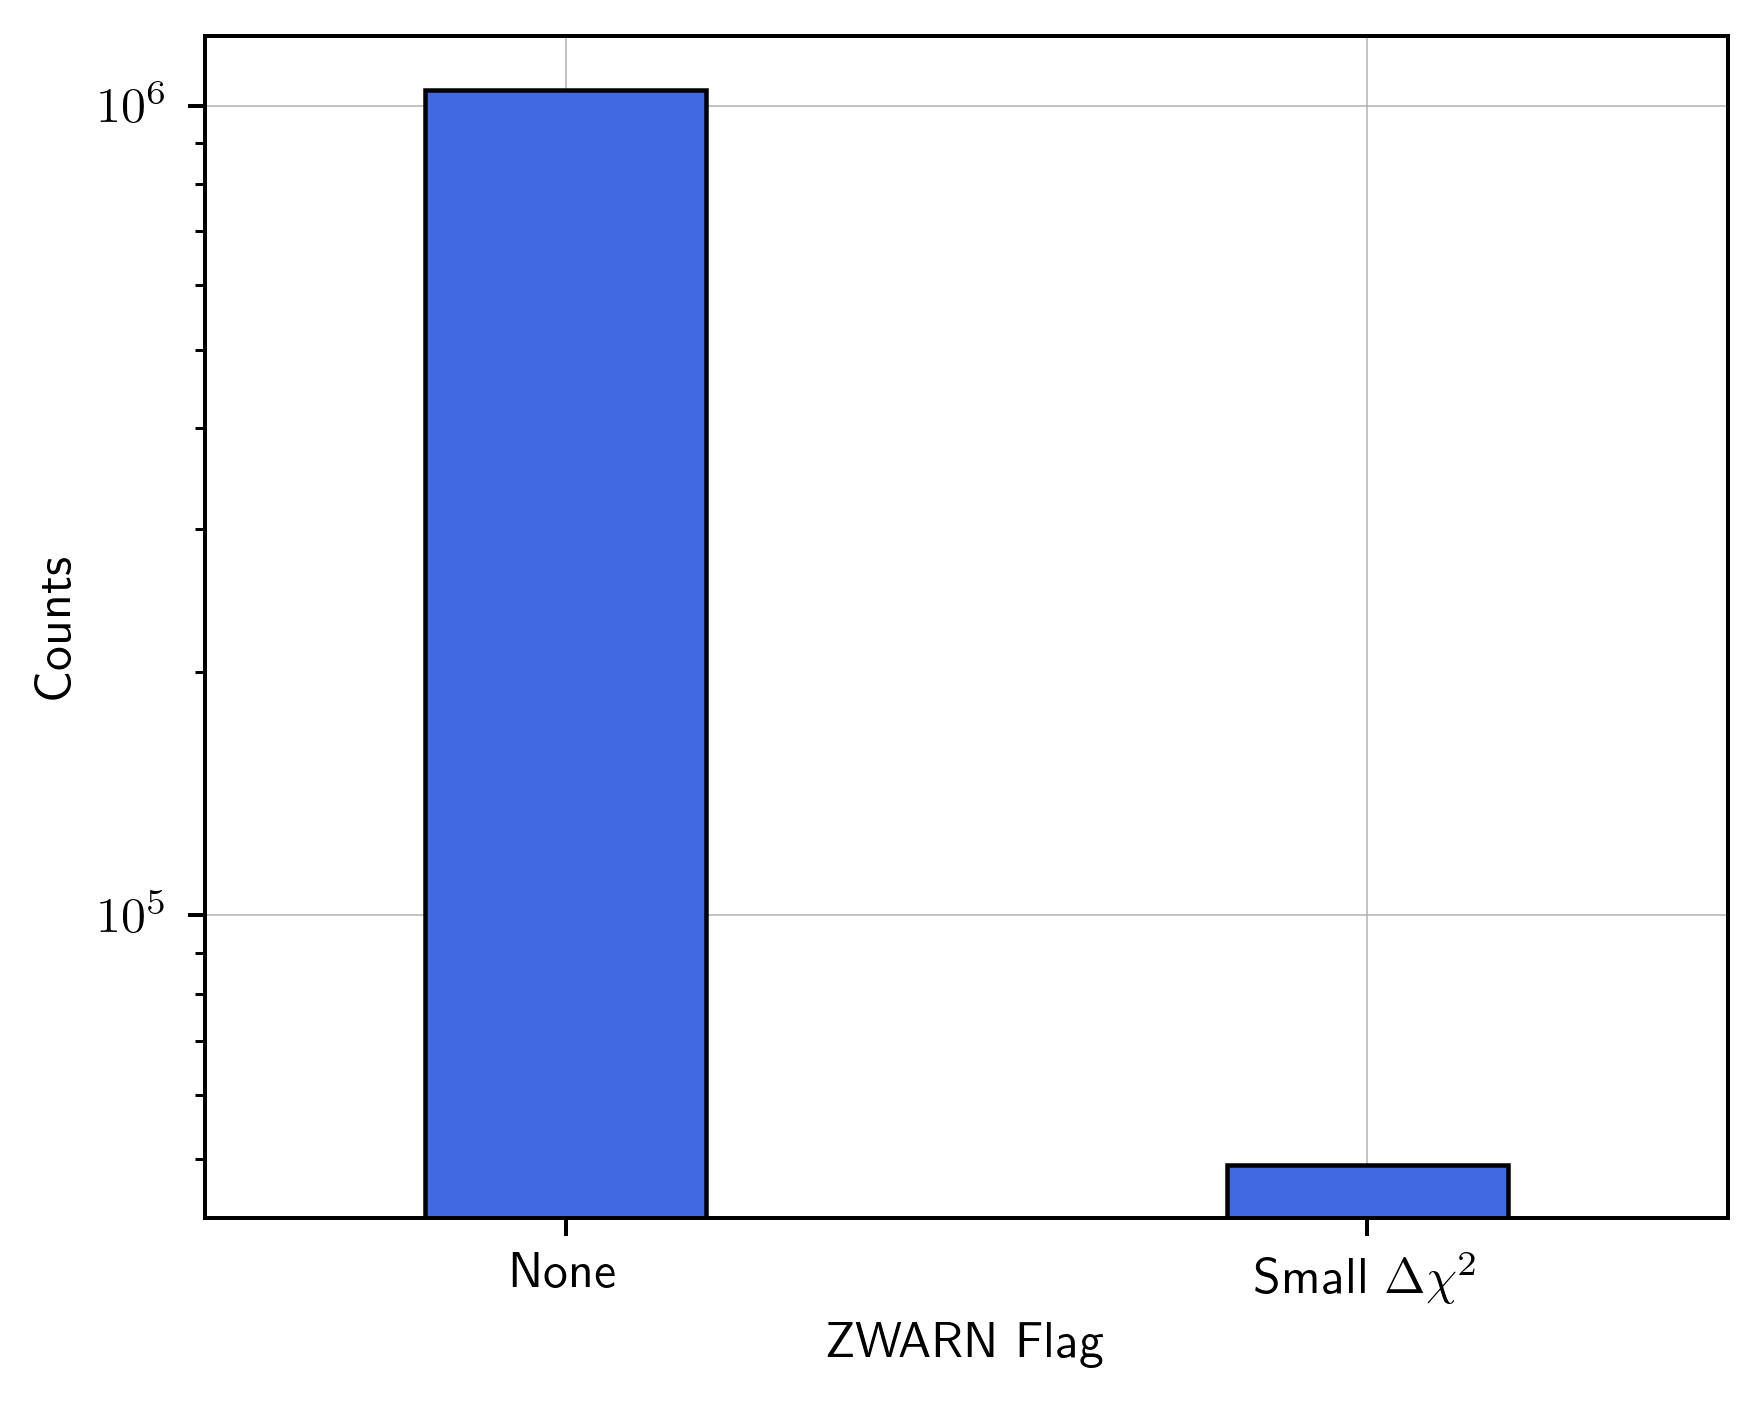

In [ ]:
fig, ax = plt.subplots(figsize=(5,4))

ax.bar(zwarn_counts['label'],
       zwarn_counts['Counts'],
       color='royalblue',
       edgecolor='black',
       width=0.35,
       linewidth=0.9)

ax.set_yscale('log')
ax.set_xlim(-0.45, len(labels) - 0.55)

ax.grid(linewidth=0.3, zorder=-1)
ax.set_axisbelow(True)

ax.set_xlabel('ZWARN Flag')
ax.set_ylabel('Counts')

plt.tight_layout()
plt.savefig('out_zflags.png', dpi=360)
plt.show()

In [3]:
from desitarget.targets import desi_mask, bgs_mask, mws_mask
import numpy as np

In [ ]:
path = '/pscratch/sd/v/vtorresg/umap_analysis/data/loa/data/processed/umap/umap_20230227_8643.npz'
file = np.load(path, allow_pickle=True)
tids = file['ids']
tids

array([39627991784885901, 39627991789077106, 39627991789079535, ...,
       39627997778545054, 39627997778544716, 39627997778547528])

In [ ]:
dff = pd.read_csv('/pscratch/sd/v/vtorresg/umap_analysis/data/loa/data/tile_spectra_counts.txt')
dff = dff.rename(columns={'tileid': 'TILEID'})
dff

,TILEID,numero_espec
0,1,3548
1,2,3551
2,3,3479
3,4,3639
4,5,3563
...,...,...
14174,83464,4020
14175,83465,4024
14176,83466,4019
14177,83467,4023


In [ ]:
out_path = '/pscratch/sd/v/vtorresg/umap_analysis/data/loa/sum/all_outliers.csv'
df = pd.read_csv(out_path)
outliers_per_tile = (df.groupby('TILEID')
                     .size().reset_index(name='N_outliers'))
outliers_per_tile

,TILEID,N_outliers
0,1,37
1,2,36
2,3,51
3,4,61
4,5,39
...,...,...
14155,83464,25
14156,83465,31
14157,83466,18
14158,83467,22


In [ ]:
df_n = outliers_per_tile.merge(dff, on='TILEID', how='inner')
df_n

,TILEID,N_outliers,numero_espec
0,1,37,3548
1,2,36,3551
2,3,51,3479
3,4,61,3639
4,5,39,3563
...,...,...,...
14155,83464,25,4020
14156,83465,31,4024
14157,83466,18,4019
14158,83467,22,4023


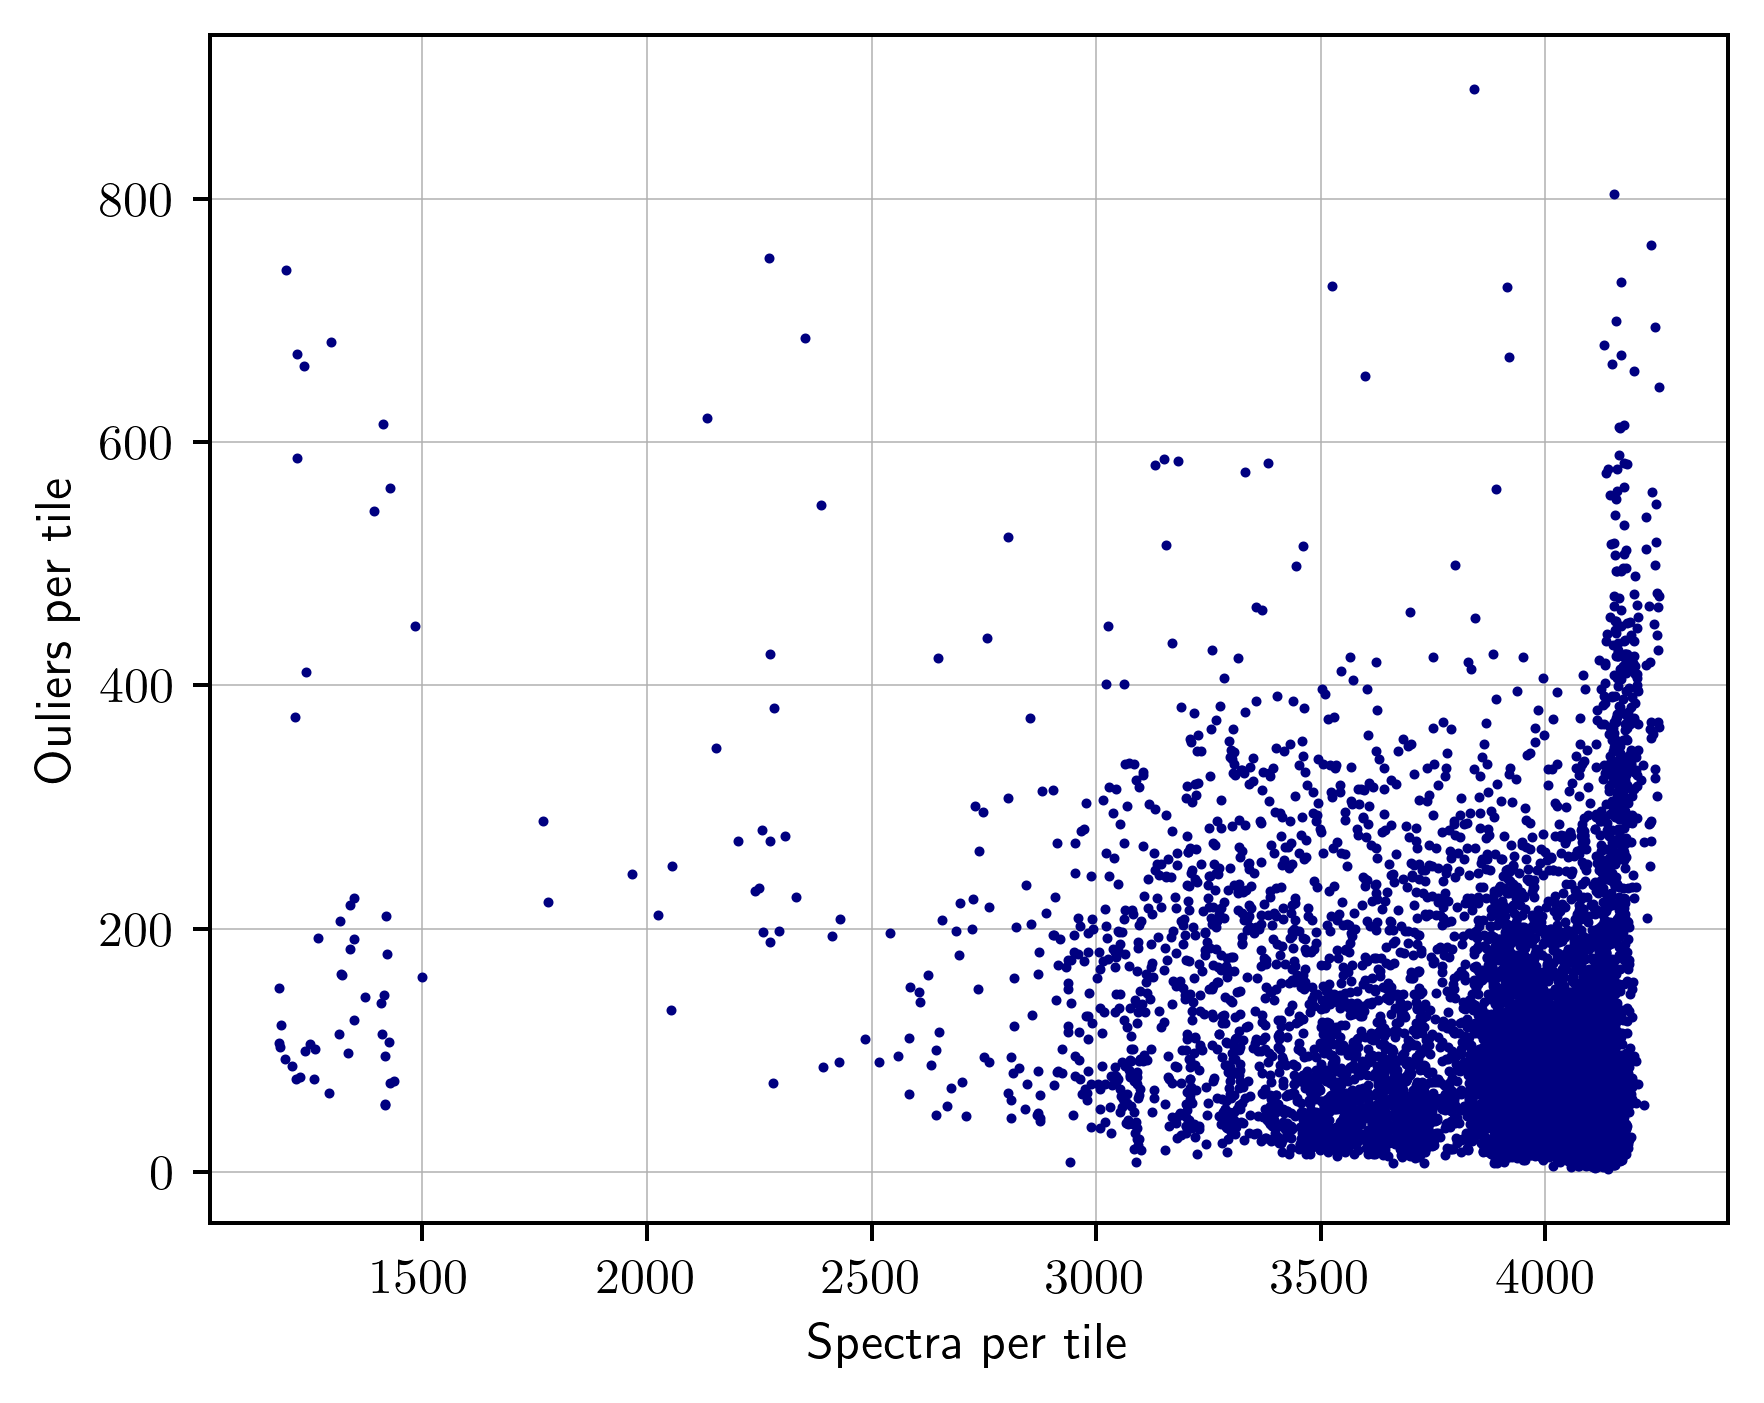

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(df_n['numero_espec'], df_n['N_outliers'], s=1., c='navy')

ax.grid(linewidth=0.3, zorder=-1)
ax.set_axisbelow(True)

ax.set_xlabel('Spectra per tile')
ax.set_ylabel('Ouliers per tile')

plt.tight_layout()
plt.savefig('out_spec.png', dpi=360)
plt.show()

In [83]:
df_n['f'] = df_n['N_outliers']/df_n['numero_espec']

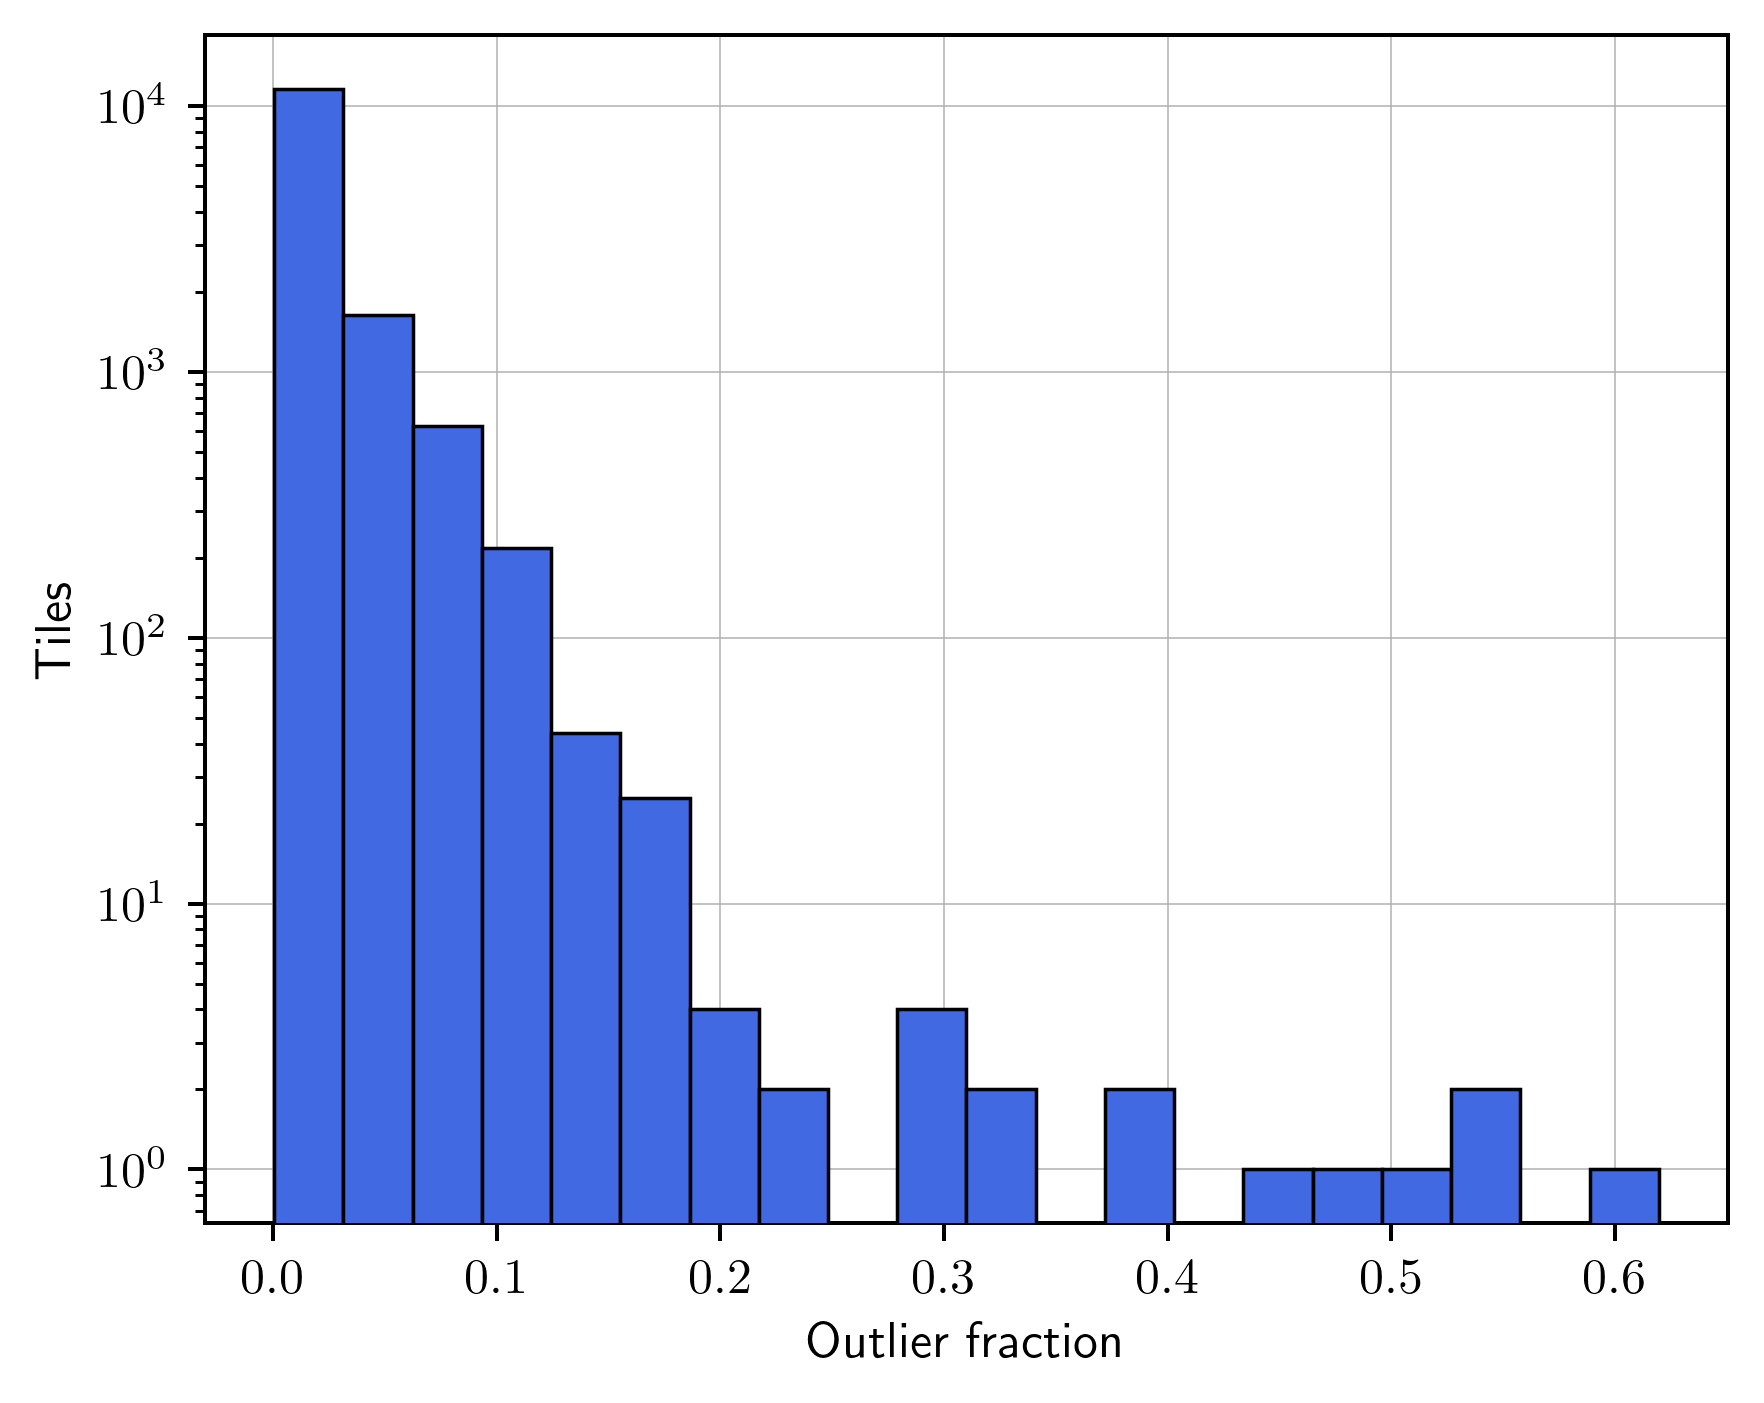

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
n_bins = 20

plt.grid(linewidth=0.3, zorder=-1)
ax.hist(df_n['f'], bins=n_bins, color='royalblue', edgecolor='black', 
        linewidth=0.7, zorder=3)

ax.set_xlabel('Outlier fraction')
ax.set_ylabel('Tiles')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('out_fraction.png', dpi=360)
plt.show()

In [141]:
dff = pd.read_csv('/pscratch/sd/v/vtorresg/umap_analysis/data/loa/sum/outlier_coadd_target_bits.csv')
dff

,NIGHT,TILE,PETAL,TARGETID,DESI_TARGET,BGS_TARGET,MWS_TARGET
0,20201216,80615,0,39628488918960090,0,0,0
1,20201216,80615,0,39628483697050350,0,0,0
2,20201216,80615,0,39628483697049697,0,0,0
3,20201216,80615,0,39628483697053483,0,0,0
4,20201216,80615,0,39628494136674203,0,0,0
...,...,...,...,...,...,...,...
1095811,20240409,9203,8,39628130062703971,655394,0,0
1095812,20240409,9203,8,39628130062700740,1179778,0,0
1095813,20240409,9203,9,39628124194869235,655394,0,0
1095814,20240409,9203,9,39628106578792402,65537,0,0


In [ ]:
def has_bit_array(values, mask, name):
    values = values.astype(np.int64)
    return (values & mask[name]) != 0

desi_target = dff['DESI_TARGET'].values.astype(np.int64)

In [ ]:
is_bgs = has_bit_array(desi_target, desi_mask, 'BGS_ANY')

is_lrg = (has_bit_array(desi_target, desi_mask, 'LRG')
    | has_bit_array(desi_target, desi_mask, 'LGE')
    | has_bit_array(desi_target, desi_mask, 'LRG_NORTH')
    | has_bit_array(desi_target, desi_mask, 'LRG_SOUTH')
    | has_bit_array(desi_target, desi_mask, 'LGE_NORTH')
    | has_bit_array(desi_target, desi_mask, 'LGE_SOUTH'))

is_elg = (has_bit_array(desi_target, desi_mask, 'ELG')
    | has_bit_array(desi_target, desi_mask, 'ELG_LOP')
    | has_bit_array(desi_target, desi_mask, 'ELG_HIP')
    | has_bit_array(desi_target, desi_mask, 'ELG_VLO')
    | has_bit_array(desi_target, desi_mask, 'ELG_NORTH')
    | has_bit_array(desi_target, desi_mask, 'ELG_SOUTH')
    | has_bit_array(desi_target, desi_mask, 'ELG_LOP_NORTH')
    | has_bit_array(desi_target, desi_mask, 'ELG_LOP_SOUTH')
    | has_bit_array(desi_target, desi_mask, 'ELG_VLO_NORTH')
    | has_bit_array(desi_target, desi_mask, 'ELG_VLO_SOUTH'))

is_qso = (has_bit_array(desi_target, desi_mask, 'QSO')
    | has_bit_array(desi_target, desi_mask, 'QSO_HIZ')
    | has_bit_array(desi_target, desi_mask, 'QSO_NORTH')
    | has_bit_array(desi_target, desi_mask, 'QSO_SOUTH'))

is_mws = has_bit_array(desi_target, desi_mask, 'MWS_ANY')

is_std = (has_bit_array(desi_target, desi_mask, 'STD_FAINT')
    | has_bit_array(desi_target, desi_mask, 'STD_BRIGHT')
    | has_bit_array(desi_target, desi_mask, 'STD_WD'))

In [ ]:
category_counts = pd.DataFrame({'CATEGORY': ['BGS', 'LRG', 'ELG', 'QSO', 'MWS', 'STD'],
                                'Counts': [is_bgs.sum(),
                                           is_lrg.sum(),
                                           is_elg.sum(),
                                           is_qso.sum(),
                                           is_mws.sum(),
                                           is_std.sum()]})
print(category_counts)

  CATEGORY  Counts
0      BGS  295135
1      LRG   79907
2      ELG  117842
3      QSO   34128
4      MWS  505965
5      STD   16542


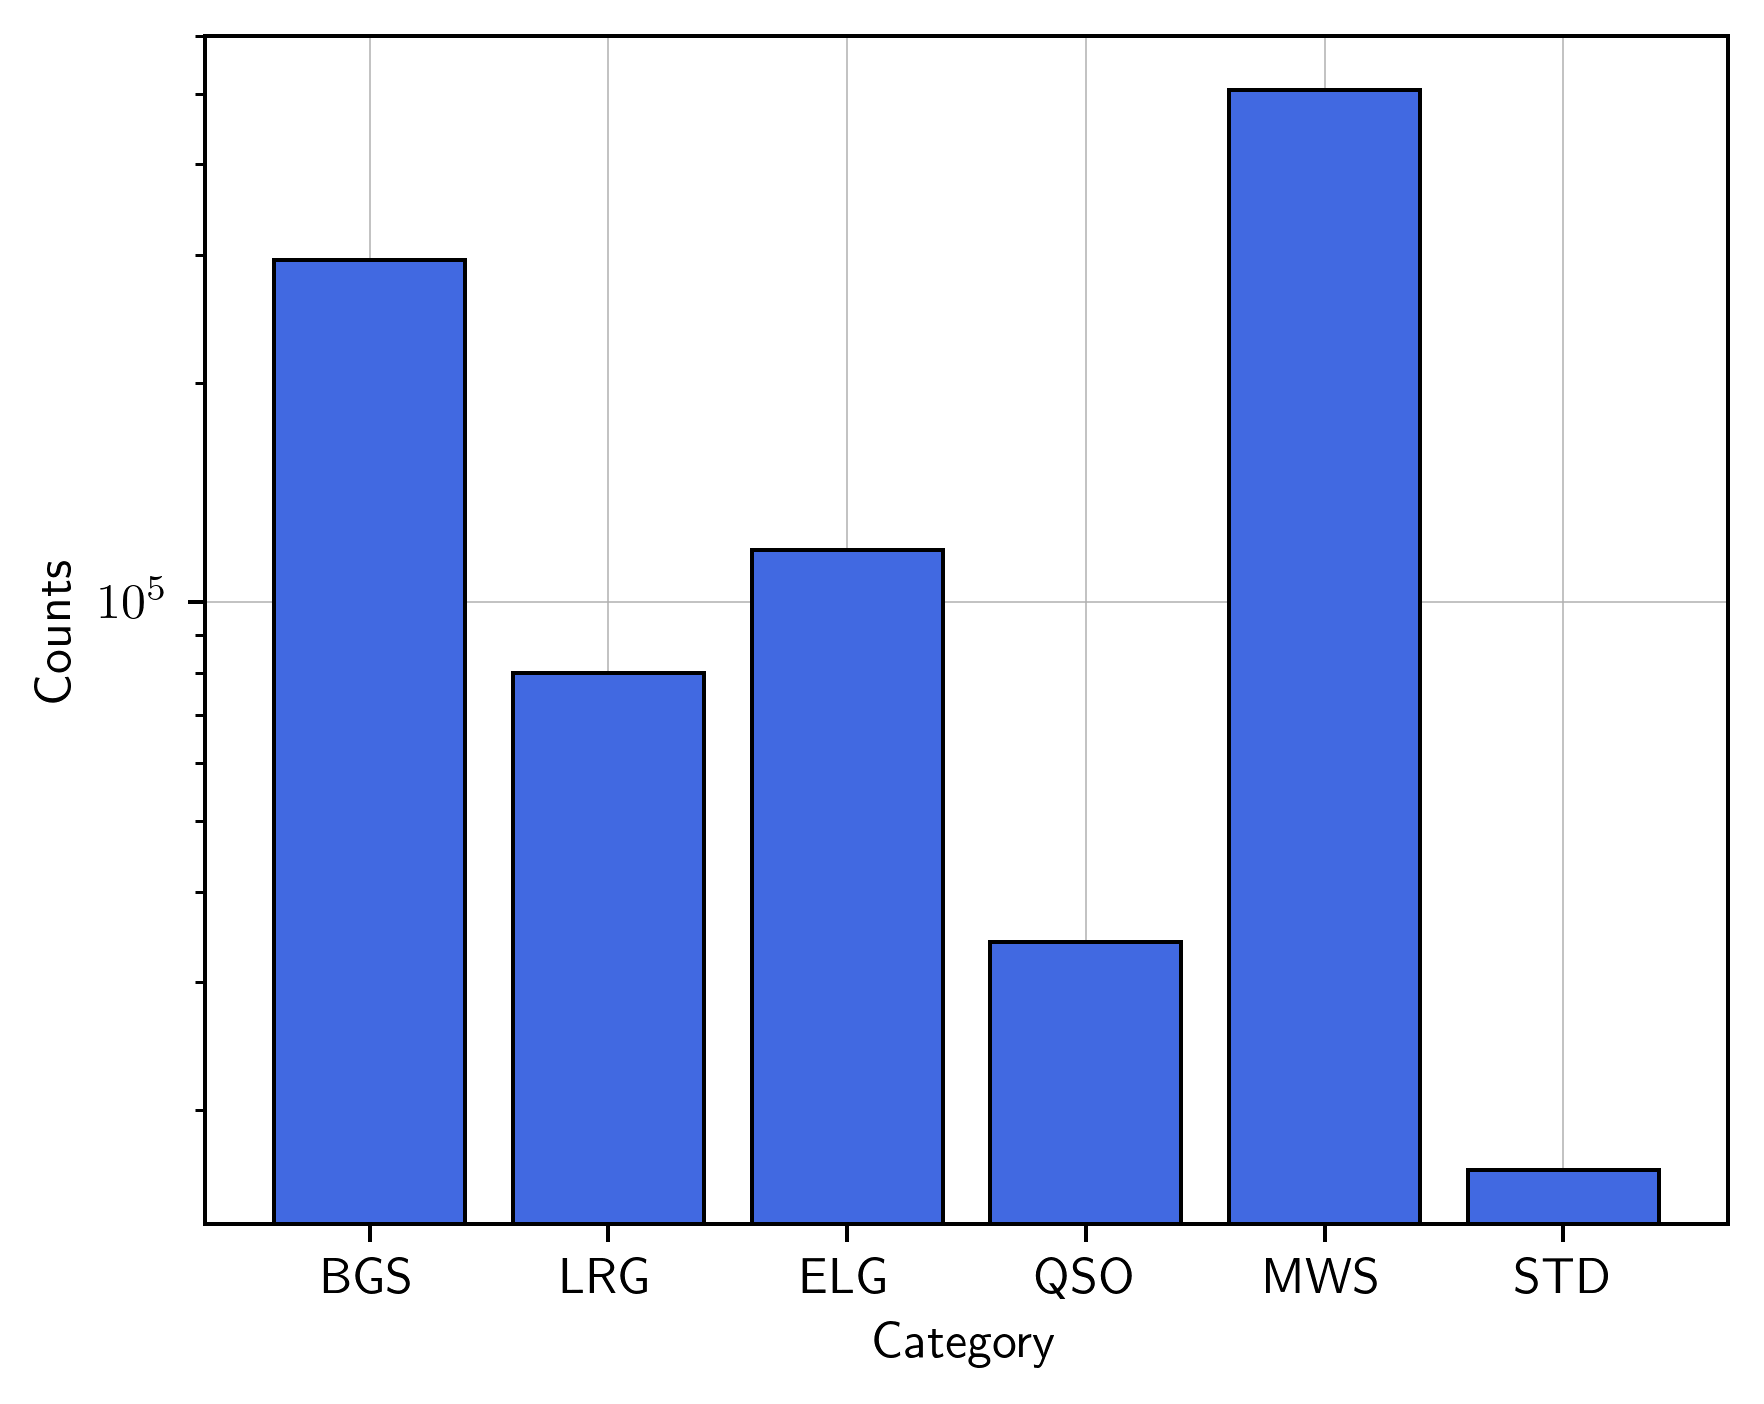

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.bar(category_counts['CATEGORY'],
       category_counts['Counts'],
       width=0.8, color='royalblue',
       edgecolor='black', linewidth=0.8)

ax.set_yscale('log')

ax.grid(linewidth=0.3, zorder=-1)
ax.set_axisbelow(True)

ax.set_xlabel('Category')
ax.set_ylabel('Counts')

plt.tight_layout()
plt.savefig('out_categories.png', dpi=360)
plt.show()